# Business Understanding

### BO1 : Detect potential health risks early

* Use real-world customer interactions and feedback to identify harmful patterns that individual users or practitioners might miss.

* Prevent adverse effects by spotting problematic supplement combinations, over consumption, or ingredient sensitivities before they affect many clients.

### DSO1 : Implement an AI-Powered Safety Monitoring System

* Deploy an AI system that analyzes conversations, reviews, and feedback about supplements and care products.

* Detect unusual patterns such as reported side effects, product interactions, or region-specific issues.

* Provide alerts to the company to act proactively and protect customer health.
*******************
### BO2: Cut training and operational costs

* Replace expensive in-person sessions and printed materials with digital alternatives.

* Improve training quality while eliminating travel and material expenditures.

### DSO2: Launch a Virtual Training and Interaction Platform

* Establish a digital academy featuring AI patient simulations and interactive online modules for global, 24/7 access.

* Eliminate travel and printing costs through this scalable solution.
*******************
### BO3: Simplify and Secure the Creation of Compliant Product Indications

* Reduce compliance risks by automatically generating indications that follow regulatory rules before they are shared.
* Save time and ensure consistency by delivering ready-to-use reports and presentations that are clear, accurate, and easy to share with doctors.

### DSO3: Implement an AI-Powered Compliant Indication Generation Module

* Develop a system that analyzes product data, detects non-compliant terms (e.g., forbidden words, disease claims), and rewrites indications based on regulatory guidelines.
* Automatically enrich outputs with safety disclaimers and generate structured reports and presentation slides, ensuring compliant and ready-to-use deliverables.
*******************
### BO4: Prevent Loss of Key Healthcare Professionals
* Identify doctors and pharmacists who may stop prescribing or engaging with your products before they do.
* Detect early disengagement signals during live delegate-HCP conversations through voice tone and sentiment analysis, not just after the fact.
### DSO4: Deploy an AI-Powered HCP Engagement & Churn Predictor
* Implement a multimodal AI system that analyzes real-time delegate-HCP conversation audio within the AVATAR platform to detect engagement risk.
* Use Speech Emotion Recognition (SER) to extract Valence-Arousal-Dominance (VAD) from the HCP's voice, combined with text sentiment analysis of the transcribed conversation via Whisper STT.
* Apply a fusion layer that merges voice emotion and text sentiment signals to detect "tonal flattening" — the early warning pattern where an HCP shifts from frustrated/engaged to neutral/indifferent.

# Data Acquisition and Understanding

## DSO1: Implement an AI-Powered Safety Monitoring System

## DSO2: Launch a Virtual Training and Interaction Platform

### Data Collection

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, get_dataset_config_names
import warnings
warnings.filterwarnings('ignore')

# Configuration du style des graphiques
plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("DATA ACQUISITION & UNDERSTANDING - DSO2".center(80))
print("=" * 80)

                    DATA ACQUISITION & UNDERSTANDING - DSO2                     


In [ ]:
# ==========================================
# 2. DATA COLLECTION
# ==========================================

print("\nLoading datasets from Hugging Face...")

wikimedqa = load_dataset("sileod/wikimedqa", "medwiki")
pubmedqa = load_dataset("qiaojin/PubMedQA", "pqa_artificial")

df_wiki = pd.DataFrame(wikimedqa["train"])
df_pubmed = pd.DataFrame(pubmedqa["train"])

print("Datasets loaded successfully!")
print("WikiMedQA:", df_wiki.shape)
print("PubMedQA:", df_pubmed.shape)


Loading datasets from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

medwiki/train-00000-of-00001-84980e27b39(…):   0%|          | 0.00/65.9M [00:00<?, ?B/s]

medwiki/validation-00000-of-00001-c799ca(…):   0%|          | 0.00/3.69M [00:00<?, ?B/s]

medwiki/test-00000-of-00001-a7faee894788(…):   0%|          | 0.00/3.69M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3757 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

pqa_artificial/train-00000-of-00001.parq(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211269 [00:00<?, ? examples/s]

Datasets loaded successfully!
WikiMedQA: (67608, 11)
PubMedQA: (211269, 5)


## DSO3

## DSO4

### Data collection

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy import stats


In [ ]:
df_hourly = pd.read_csv('saleshourly.csv')
df_daily = pd.read_csv('salesdaily.csv')
df_weekly = pd.read_csv('salesweekly.csv')
df_monthly = pd.read_csv('salesmonthly.csv')

print("--- Hourly Data ---")
print(df_hourly.head())
print(df_hourly.info())
print("\n--- Daily Data ---")
print(df_daily.head())
print(df_daily.info())
print("\n--- Weekly Data ---")
print(df_weekly.head())
print(df_weekly.info())
print("\n--- Monthly Data ---")
print(df_monthly.head())
print(df_monthly.info())

In [ ]:
df_hourly['date'] = pd.to_datetime(df_hourly['datum'])
df_hourly['year_month'] = df_hourly['date'].dt.to_period('M')

df_daily['date'] = pd.to_datetime(df_daily['datum'])
df_daily['year_month'] = df_daily['date'].dt.to_period('M')

df_weekly['date'] = pd.to_datetime(df_weekly['datum'])
df_weekly['year_month'] = df_weekly['date'].dt.to_period('M')

df_monthly['date'] = pd.to_datetime(df_monthly['datum'])
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

print("\n 'year_month' columns created for all DataFrames")

In [ ]:
df_hourly_monthly = df_hourly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Hourly data aggregated: {len(df_hourly_monthly)} months")

df_daily_monthly = df_daily.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Daily data aggregated: {len(df_daily_monthly)} months")

df_weekly_monthly = df_weekly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Weekly data aggregated: {len(df_weekly_monthly)} months")

df_monthly_clean = df_monthly[['year_month', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].copy()
print(f" Monthly data: {len(df_monthly_clean)} months")

In [ ]:

print("\n--- Merging monthly data ---")

all_months = pd.concat([
    df_hourly_monthly['year_month'],
    df_daily_monthly['year_month'],
    df_weekly_monthly['year_month'],
    df_monthly_clean['year_month']
]).unique()
all_months = pd.Series(sorted(all_months)).reset_index(drop=True)
df_final_monthly = pd.DataFrame({'year_month': all_months})
print(f"✓ Period covered: {len(df_final_monthly)} unique months")

def merge_with_priority(df_base, df_new, priority_name):
    """Merges df_new into df_base with a suffix for traceability"""
    return df_base.merge(
        df_new,
        on='year_month',
        how='left',
        suffixes=('', f'_{priority_name}')
    )

# Priority 1: Monthly data (most reliable source for the month)
df_final_monthly = merge_with_priority(df_final_monthly, df_monthly_clean, 'monthly')

# Priority 2: Aggregated weekly data
df_final_monthly = merge_with_priority(df_final_monthly, df_weekly_monthly, 'weekly')

# Priority 3: Aggregated daily data
df_final_monthly = merge_with_priority(df_final_monthly, df_daily_monthly, 'daily')

# Priority 4: Aggregated hourly data
df_final_monthly = merge_with_priority(df_final_monthly, df_hourly_monthly, 'hourly')


for col in ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']:
    # Create a list of columns in priority order
    priority_cols = [
        f'{col}_monthly',
        f'{col}_weekly',
        f'{col}_daily',
        f'{col}_hourly'
    ]

    df_final_monthly[col] = np.nan

    for pcol in priority_cols:
        if pcol in df_final_monthly.columns:
            df_final_monthly[col] = df_final_monthly[col].fillna(df_final_monthly[pcol])
            df_final_monthly.drop(columns=[pcol], inplace=True)

    df_final_monthly[col] = df_final_monthly[col].round(2)

print(" Merge completed with priority: monthly > weekly > daily > hourly")

In [ ]:
df_final_monthly['year'] = df_final_monthly['year_month'].dt.year
df_final_monthly['month'] = df_final_monthly['year_month'].dt.month
df_final_monthly['quarter'] = df_final_monthly['year_month'].dt.quarter

df_final_monthly['date'] = df_final_monthly['year_month'].dt.to_timestamp()

print(" Temporal columns added")


sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_final_monthly['total_sales'] = df_final_monthly[sales_columns].sum(axis=1).round(2)

print(" Total sales calculated")



df_final_monthly = df_final_monthly.sort_values('date').reset_index(drop=True)


print("\n--- Final monthly DataFrame overview ---")
print(f"Dimensions: {df_final_monthly.shape[0]} rows, {df_final_monthly.shape[1]} columns")
print(f"Period: {df_final_monthly['date'].min().date()} to {df_final_monthly['date'].max().date()}")
print("\nFirst rows:")
print(df_final_monthly.head(12).to_string())  # Display a full year

print("\nLast rows:")
print(df_final_monthly.tail(12).to_string())

print("\nDescriptive statistics:")
print(df_final_monthly[sales_columns + ['total_sales']].describe().round(2))

In [ ]:
df_final_monthly.to_excel('hcp_sales_monthly_final.xlsx', index=False)
print("\n File 'hcp_sales_monthly_final.xlsx' created successfully!")

print("\n--- Quick quality check ---")
print(f"Missing values: {df_final_monthly[sales_columns].isnull().sum().sum()}")
print(f"Duplicate months: {df_final_monthly['year_month'].duplicated().sum()}")

# Check month continuity
all_months_expected = pd.period_range(
    start=df_final_monthly['year_month'].min(),
    end=df_final_monthly['year_month'].max(),
    freq='M'
)
missing_months = set(all_months_expected) - set(df_final_monthly['year_month'])
if missing_months:
    print(f"⚠️ Missing months: {sorted([str(m) for m in missing_months])}")
else:
    print(" Complete monthly series")

print("\n" + "="*60)
print("ANALYSIS COMPLETED - MONTHLY FILE READY")
print("="*60)

### Data augmentation

In [ ]:
df_original = pd.read_excel('hcp_sales_monthly_final.xlsx')
print(f"\n Original data: {df_original.shape[0]} months, {df_original.shape[1]} columns")
print(f"Period: {df_original['date'].min()} to {df_original['date'].max()}")

df_original['date'] = pd.to_datetime(df_original['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

if 'year_month' in df_original.columns:
    df_original = df_original.drop(columns=['year_month'])

for col in sales_columns:
    if col in df_original.columns:
        df_original[col] = pd.to_numeric(df_original[col], errors='coerce').fillna(0)

df_original['total_sales'] = df_original[sales_columns].sum(axis=1)

print(f" Data prepared: {df_original.shape[0]} rows, {df_original.shape[1]} columns")

In [ ]:
# ======================================================================
# METHOD 1: PRODUCT DECOMPOSITION (create rows by category)
# ======================================================================
print("\n" + "="*60)
print("METHOD 1: PRODUCT CATEGORY DECOMPOSITION")
print("="*60)

product_categories = {
    'Anti-inflammatories': ['M01AB', 'M01AE'],
    'Analgesics': ['N02BA', 'N02BE'],
    'Psychotropics': ['N05B', 'N05C'],
    'Respiratory': ['R03', 'R06']
}

category_rows = []
for idx, row in df_original.iterrows():
    for category, products in product_categories.items():
        category_sales = sum([row[prod] for prod in products])
        new_row = {
            'date': row['date'],
            'year': int(row['year']) if 'year' in row else row['date'].year,
            'month': int(row['month']) if 'month' in row else row['date'].month,
            'quarter': int(row['quarter']) if 'quarter' in row else (row['date'].month-1)//3 + 1,
            'category': category,
            'sales': float(category_sales),
            'product_count': len(products)
        }
        category_rows.append(new_row)

df_by_category = pd.DataFrame(category_rows)
print(f" After category decomposition: {df_by_category.shape[0]} rows")

In [ ]:
# ======================================================================
# METHOD 2: CREATING SYNTHETIC MONTHS THROUGH INTERPOLATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 2: INTERPOLATION TO CREATE ADDITIONAL MONTHS")
print("="*60)

all_months = pd.date_range(start=df_original['date'].min(),
                           end=df_original['date'].max(),
                           freq='MS')

df_temp = df_original.set_index('date')
df_interpolated = df_temp.reindex(all_months)

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].interpolate(method='linear').round(2)

df_interpolated['year'] = df_interpolated.index.year
df_interpolated['month'] = df_interpolated.index.month
df_interpolated['quarter'] = df_interpolated.index.quarter

df_interpolated = df_interpolated.reset_index().rename(columns={'index': 'date'})

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].fillna(method='bfill').fillna(method='ffill')

print(f" After interpolation: {df_interpolated.shape[0]} months")
print(f"   (+{df_interpolated.shape[0] - df_original.shape[0]} interpolated months)")

In [ ]:
# ======================================================================
# METHOD 3: CREATING MONTHLY FEATURES (CYCLICAL FEATURES)
# ======================================================================
print("\n" + "="*60)
print("METHOD 3: CREATING CYCLICAL FEATURES")
print("="*60)

df_features = df_original.copy()

if 'month' not in df_features.columns:
    df_features['month'] = df_features['date'].dt.month
if 'quarter' not in df_features.columns:
    df_features['quarter'] = df_features['date'].dt.quarter
if 'year' not in df_features.columns:
    df_features['year'] = df_features['date'].dt.year

df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12).astype(float)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12).astype(float)

df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4).astype(float)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4).astype(float)

df_features['is_winter'] = df_features['month'].isin([12, 1, 2]).astype(int)
df_features['is_spring'] = df_features['month'].isin([3, 4, 5]).astype(int)
df_features['is_summer'] = df_features['month'].isin([6, 7, 8]).astype(int)
df_features['is_fall'] = df_features['month'].isin([9, 10, 11]).astype(int)

print(f" Features added: {df_features.shape[1] - df_original.shape[1]} new columns")

In [ ]:
# ======================================================================
# METHOD 4: BOOTSTRAP DATA GENERATION (WITH NOISE)
# ======================================================================
print("\n" + "="*60)
print("METHOD 4: BOOTSTRAP WITH CONTROLLED NOISE ADDITION")
print("="*60)

np.random.seed(42)

std_per_product = df_original[sales_columns].std()
mean_per_product = df_original[sales_columns].mean()

n_bootstrap = 20  # Reduced to avoid overload
bootstrap_rows = []

for i in range(n_bootstrap):
    n_samples = max(5, int(0.6 * len(df_original)))
    sample_indices = np.random.choice(df_original.index, size=n_samples, replace=True)
    sample = df_original.loc[sample_indices].copy()

    for col in sales_columns:
        noise = np.random.normal(0, std_per_product[col] * 0.05, size=len(sample))
        sample[col] = sample[col] + noise
        sample[col] = sample[col].clip(lower=0)  # No negative sales

    sample['total_sales'] = sample[sales_columns].sum(axis=1)
    sample['bootstrap_id'] = i
    sample['source_detail'] = f'bootstrap_{i}'

    bootstrap_rows.append(sample)

if bootstrap_rows:
    df_bootstrap = pd.concat(bootstrap_rows, ignore_index=True)
    print(f" After bootstrap: {df_bootstrap.shape[0]} rows")
else:
    df_bootstrap = pd.DataFrame()

In [ ]:
# ======================================================================
# METHOD 5: CREATING SYNTHETIC MONTHS THROUGH TEMPORAL AUGMENTATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 5: TEMPORAL AUGMENTATION")
print("="*60)

time_shifts = [-2, -1, 1, 2]  # shifts in months
shifted_rows = []

for shift in time_shifts:
    df_shifted = df_original.copy()

    new_dates = []
    for date in df_shifted['date']:
        new_date = date + pd.DateOffset(months=shift)
        new_dates.append(new_date)

    df_shifted['date'] = new_dates
    df_shifted['shift'] = shift

    df_shifted['year'] = df_shifted['date'].dt.year
    df_shifted['month'] = df_shifted['date'].dt.month
    df_shifted['quarter'] = df_shifted['date'].dt.quarter

    min_date = df_original['date'].min() - pd.DateOffset(months=6)
    max_date = df_original['date'].max() + pd.DateOffset(months=6)

    mask = (df_shifted['date'] >= min_date) & (df_shifted['date'] <= max_date)
    df_shifted = df_shifted[mask]

    if len(df_shifted) > 0:
        shifted_rows.append(df_shifted)

if shifted_rows:
    df_shifted_all = pd.concat(shifted_rows, ignore_index=True)
    print(f" After temporal shifts: {df_shifted_all.shape[0]} rows")
else:
    df_shifted_all = pd.DataFrame()

In [ ]:

print("\n" + "="*60)
print("PREPARING DATASETS FOR CONCATENATION")
print("="*60)

base_columns = ['date', 'year', 'month', 'quarter', 'total_sales'] + sales_columns

def clean_dataframe(df, source_name):
    if df is None or len(df) == 0:
        return None

    df_clean = df.copy()

    for col in base_columns:
        if col not in df_clean.columns and col != 'source':
            if col in sales_columns:
                df_clean[col] = 0.0
            elif col in ['year', 'month', 'quarter']:
                if 'date' in df_clean.columns:
                    df_clean[col] = df_clean['date'].dt.year if col == 'year' else \
                                   df_clean['date'].dt.month if col == 'month' else \
                                   df_clean['date'].dt.quarter

    df_clean['source'] = source_name

    available_cols = [col for col in base_columns + ['source'] if col in df_clean.columns]

    return df_clean[available_cols]

datasets_to_concat = []

df_orig_clean = clean_dataframe(df_original, 'original')
if df_orig_clean is not None:
    datasets_to_concat.append(df_orig_clean)
    print(f" Original dataset: {len(df_orig_clean)} rows")

df_features_clean = clean_dataframe(df_features, 'with_features')
if df_features_clean is not None:
    datasets_to_concat.append(df_features_clean)
    print(f" Features dataset: {len(df_features_clean)} rows")

df_interp_clean = clean_dataframe(df_interpolated, 'interpolated')
if df_interp_clean is not None and len(df_interp_clean) > len(df_original):
    orig_dates = set(df_original['date'].dt.strftime('%Y-%m-%d'))

    new_dates_mask = ~df_interp_clean['date'].dt.strftime('%Y-%m-%d').isin(orig_dates)
    df_interp_new = df_interp_clean[new_dates_mask].copy()

    if len(df_interp_new) > 0:
        datasets_to_concat.append(df_interp_new)
        print(f" Interpolated dataset (new months): {len(df_interp_new)} rows")

if not df_bootstrap.empty:
    df_bootstrap_clean = clean_dataframe(df_bootstrap, 'bootstrap')
    if df_bootstrap_clean is not None and len(df_bootstrap_clean) > 0:
        if len(df_bootstrap_clean) > 100:
            df_bootstrap_clean = df_bootstrap_clean.sample(n=100, random_state=42)
        datasets_to_concat.append(df_bootstrap_clean)
        print(f" Bootstrap dataset: {len(df_bootstrap_clean)} rows")

if not df_shifted_all.empty:
    df_shifted_clean = clean_dataframe(df_shifted_all, 'shifted')
    if df_shifted_clean is not None and len(df_shifted_clean) > 0:
        # Limit to 80 rows maximum
        if len(df_shifted_clean) > 80:
            df_shifted_clean = df_shifted_clean.sample(n=80, random_state=42)
        datasets_to_concat.append(df_shifted_clean)
        print(f" Shifted dataset: {len(df_shifted_clean)} rows")

for category, products in product_categories.items():
    cat_data = df_by_category[df_by_category['category'] == category].copy()

    if len(cat_data) > 0:
        cat_expanded = []
        for _, row in cat_data.iterrows():
            new_row = {
                'date': row['date'],
                'year': int(row['year']),
                'month': int(row['month']),
                'quarter': int(row['quarter']),
                'total_sales': float(row['sales']),
                'source': f'category_{category}'
            }
            for prod in products:
                new_row[prod] = float(row['sales'] / row['product_count'])
            for prod in sales_columns:
                if prod not in new_row:
                    new_row[prod] = 0.0
            cat_expanded.append(new_row)

        if cat_expanded:
            df_cat = pd.DataFrame(cat_expanded)
            datasets_to_concat.append(df_cat)
            print(f" Category {category} dataset: {len(df_cat)} rows")

In [ ]:
print("\n" + "="*60)
print("FINAL CONCATENATION")
print("="*60)

if len(datasets_to_concat) == 0:
    print(" No datasets to concatenate!")
    exit()

df_combined = pd.concat(datasets_to_concat, ignore_index=True, sort=False)

for col in sales_columns + ['total_sales']:
    if col in df_combined.columns:
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce').fillna(0).astype(float)

df_combined['date'] = pd.to_datetime(df_combined['date'])

df_combined = df_combined.sort_values('date').reset_index(drop=True)

print(f"\n FINAL RESULT:")
print(f"   - Original dataset: {df_original.shape[0]} rows")
print(f"   - Augmented dataset: {df_combined.shape[0]} rows")
print(f"   - Augmentation: {df_combined.shape[0] / df_original.shape[0]:.1f}x")
print(f"   - Sources: {df_combined['source'].nunique()} different types")

# Save
df_combined.to_excel('hcp_sales_monthly_augmented.xlsx', index=False)
print("\n✅ File 'hcp_sales_monthly_augmented.xlsx' created successfully!")


print("\n" + "="*60)
print("COMPARATIVE STATISTICS")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Number of rows', 'Mean sales', 'Median sales', 'Std deviation', 'Min', 'Max'],
    'Original': [
        df_original.shape[0],
        df_original['total_sales'].mean(),
        df_original['total_sales'].median(),
        df_original['total_sales'].std(),
        df_original['total_sales'].min(),
        df_original['total_sales'].max()
    ],
    'Augmented': [
        df_combined.shape[0],
        df_combined['total_sales'].mean(),
        df_combined['total_sales'].median(),
        df_combined['total_sales'].std(),
        df_combined['total_sales'].min(),
        df_combined['total_sales'].max()
    ]
})

print(comparison.round(2).to_string(index=False))

print("\n Distribution by source:")
source_dist = df_combined['source'].value_counts()
for src, count in source_dist.items():
    print(f"   - {src}: {count} rows ({count/len(df_combined)*100:.1f}%)")

print("\n" + "="*80)
print("DATA AUGMENTATION COMPLETED SUCCESSFULLY!")
print("="*80)

## Pre-treatment

## DSO2

In [ ]:

# ==========================================
# 4. CHECK DATA QUALITY
# ==========================================

print("\n" + "="*50)
print("DATA QUALITY CHECK")
print("="*50)

# Missing value percentage
def missing_percentage(df):
    return (df.isnull().sum() / len(df)) * 100

print("\nMissing % - WikiMedQA")
print(missing_percentage(df_wiki))

print("\nMissing % - PubMedQA")
print(missing_percentage(df_pubmed))


In [ ]:

# ==========================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("\nGenerating EDA Visualizations...")

# --- Text Length Analysis ---
if "text" in df_wiki.columns:
    df_wiki["text_length"] = df_wiki["text"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_wiki["text_length"], bins=50)
    plt.title("WikiMedQA - Text Length Distribution")
    plt.show()

if "question" in df_pubmed.columns:
    df_pubmed["question_length"] = df_pubmed["question"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_pubmed["question_length"], bins=50)
    plt.title("PubMedQA - Question Length Distribution")
    plt.show()


# --- Outlier Detection using Boxplot ---
if "text_length" in df_wiki.columns:
    plt.figure()
    sns.boxplot(x=df_wiki["text_length"])
    plt.title("WikiMedQA - Outlier Detection (Text Length)")
    plt.show()

if "question_length" in df_pubmed.columns:
    plt.figure()
    sns.boxplot(x=df_pubmed["question_length"])
    plt.title("PubMedQA - Outlier Detection (Question Length)")
    plt.show()


# --- Label Distribution ---
if "label" in df_wiki.columns:
    plt.figure()
    df_wiki["label"].value_counts().plot(kind="bar")
    plt.title("WikiMedQA - Label Distribution")
    plt.show()

if "final_decision" in df_pubmed.columns:
    plt.figure()
    df_pubmed["final_decision"].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title("PubMedQA - Final Decision Distribution")
    plt.ylabel("")
    plt.show()

In [ ]:
# ===============================
# DATA PREPROCESSING: Drop Gamme Column
# Run this BEFORE Model 1
# ===============================

import pandas as pd
import os

def preprocess_product_catalog(input_path="extracted_products.xlsx", output_path="products.xlsx"):
    """
    Drop the Gamme column and save cleaned version
    """
    print(f"\n{'='*60}")
    print("DATA PREPROCESSING - Dropping Gamme Column")
    print(f"{'='*60}")

    # Check if input file exists
    if not os.path.exists(input_path):
        print(f"❌ Error: File not found: {input_path}")
        return None

    try:
        # Load the Excel file
        df = pd.read_excel(input_path)
        print(f"✅ Original file loaded")
        print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"   Original columns: {list(df.columns)}")

        # Show first few rows of original data
        print(f"\n📊 First 3 rows of original data:")
        print(df.head(3))

        # Identify the Gamme column (first column based on your structure)
        # Column 0 is Gamme
        gamme_col = df.columns[0]
        print(f"\n🗑️  Dropping column: '{gamme_col}' (Gamme)")

        # Drop the Gamme column
        df_cleaned = df.drop(columns=[gamme_col])

        # Show cleaned data
        print(f"\n✅ Cleaned file created")
        print(f"   New shape: {df_cleaned.shape[0]} rows × {df_cleaned.shape[1]} columns")
        print(f"   New columns: {list(df_cleaned.columns)}")

        print(f"\n📊 First 3 rows of cleaned data:")
        print(df_cleaned.head(3))

        # Save cleaned file
        df_cleaned.to_excel(output_path, index=False)
        print(f"\n💾 Cleaned file saved as: {output_path}")

        return output_path

    except Exception as e:
        print(f"❌ Error during preprocessing: {e}")
        return None

# Run the preprocessing
cleaned_file = preprocess_product_catalog("extracted_products.xlsx", "products.xlsx")

if cleaned_file:
    print(f"\n{'='*60}")
    print("✅ Preprocessing complete! Use 'produits_cleaned.xlsx' in Model 1")
    print(f"{'='*60}")
else:
    print(f"\n❌ Preprocessing failed!")


DATA PREPROCESSING - Dropping Gamme Column
✅ Original file loaded
   Shape: 10606 rows × 5 columns
   Original columns: ['Gamme', 'Produit', 'Composition', 'Indication', 'Posologie']

📊 First 3 rows of original data:
           Gamme                                            Produit  \
0    Aromessence                   Aromessence Piedarom Baume 50 ml   
1       Bielenda               Bielenda Mask Black Sugar Detox 2En1   
2  Michel-pierre  Michel Pierre Reflustop Dose De 10ml Boite 20 ...   

  Composition                                         Indication Posologie  
0         NaN  Baume pour les pieds\n\n\nContenance de 50 ml\...       NaN  
1         NaN  Masque purifiant\n\n\nÉlimine les impuretés\n\...       NaN  
2         NaN  Apaise brûlures d’estomac et reflux\n\n\nProtè...       NaN  

🗑️  Dropping column: 'Gamme' (Gamme)

✅ Cleaned file created
   New shape: 10606 rows × 4 columns
   New columns: ['Produit', 'Composition', 'Indication', 'Posologie']

📊 First 3 rows of c

## DSO4

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("EXPLORATORY ANALYSIS OF AUGMENTED MONTHLY DATA - PREPROCESSING")
print("="*80)


print("\n1. LOADING AUGMENTED MONTHLY DATA")
print("-" * 40)

try:
    df = pd.read_excel('hcp_sales_monthly_augmented.xlsx')
    print(f" AUGMENTED monthly file loaded successfully")
except FileNotFoundError:
    try:
        df = pd.read_excel('hcp_sales_monthly_final.xlsx')
        print(f"  Augmented file not found, using original file")
    except FileNotFoundError:
        print(" No file found. Please run the merge code first.")
        exit()

print(f"   - Number of rows (months): {df.shape[0]:,}")
print(f"   - Number of columns: {df.shape[1]}")
print(f"   - Period covered: from {df['date'].min()} to {df['date'].max()}")

df['date'] = pd.to_datetime(df['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
sales_columns = [col for col in sales_columns if col in df.columns]

if 'total_sales' not in df.columns and len(sales_columns) > 0:
    df['total_sales'] = df[sales_columns].sum(axis=1)

if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'quarter' not in df.columns:
    df['quarter'] = df['date'].dt.quarter

print(f"\n Data prepared: {df.shape[0]} rows, {df.shape[1]} columns")
if 'source' in df.columns:
    print(f"   - Data sources: {df['source'].nunique()} types")
    print(df['source'].value_counts().to_string())

In [ ]:

print("\n2. OVERVIEW OF MONTHLY DATA")
print("-" * 40)

print("\n First 12 months (one full year):")
print(df.head(12).to_string())

print("\n Last 12 months:")
print(df.tail(12).to_string())

print("\n General information about the monthly DataFrame:")
print(df.info())

print("\n Descriptive statistics of monthly sales:")
print(df.describe(include='all').round(2))

In [ ]:
print("\n3. MISSING VALUES ANALYSIS")
print("-" * 40)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing values': missing_values.values,
    'Percentage (%)': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing values'] > 0].sort_values('Missing values', ascending=False)

print(f"\n Total number of cells: {df.size:,}")
print(f" Total number of missing values: {df.isnull().sum().sum():,}")
print(f" Overall percentage of missing values: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

if len(missing_df) > 0:
    print("\n Details by column:")
    print(missing_df.to_string(index=False))

    # Visualization of missing values
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Bar chart
    axes[0].barh(missing_df['Column'], missing_df['Missing values'])
    axes[0].set_xlabel('Number of missing values')
    axes[0].set_title('Missing values by column')

    # Heatmap of missing values
    sns.heatmap(df[missing_df['Column']].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
    axes[1].set_title('Missing values pattern')
    axes[1].set_xlabel('Columns')

    plt.tight_layout()
    plt.show()
else:
    print(" No missing values detected in the monthly data!")

In [ ]:
print("\n4. DUPLICATES ANALYSIS")
print("-" * 40)

duplicates_exact = df.duplicated().sum()
print(f" Exact duplicate rows: {duplicates_exact} ({duplicates_exact/len(df)*100:.2f}%)")

if 'date' in df.columns:
    # Convert to string to avoid timezone issues
    date_strings = df['date'].dt.strftime('%Y-%m-%d')
    duplicates_date = date_strings.duplicated().sum()
    print(f" Duplicate dates: {duplicates_date} ({duplicates_date/len(df)*100:.2f}%)")

    if duplicates_date > 0:
        print("\n   Examples of duplicate dates (with sources):")
        dup_dates = date_strings[date_strings.duplicated(keep=False)]
        dup_sample = df[date_strings.isin(dup_dates)].sort_values('date').head(10)
        if 'source' in dup_sample.columns:
            print(dup_sample[['date', 'source', 'total_sales']].to_string())
        else:
            print(dup_sample[['date', 'total_sales']].to_string())

In [ ]:
print("\n5. OUTLIERS ANALYSIS - MONTHLY DATA")
print("-" * 40)

exclude_cols = ['date', 'year', 'month', 'quarter', 'source', 'bootstrap_id', 'shift', 'source_detail', 'unique_id']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols and col in sales_columns + ['total_sales']]

print(f" Numeric columns analyzed: {', '.join(numeric_cols)}")

outlier_stats = []

for col in numeric_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
        pct_outliers_iqr = (outliers_iqr / len(df)) * 100

        col_clean = df[col].dropna()
        if len(col_clean) > 1:
            z_scores = np.abs(stats.zscore(col_clean))
            outliers_zscore = (z_scores > 3).sum()
            pct_outliers_zscore = (outliers_zscore / len(df)) * 100
        else:
            outliers_zscore = 0
            pct_outliers_zscore = 0

        outlier_stats.append({
            'Column': col,
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Mean': df[col].mean(),
            'Median': df[col].median(),
            'Std Dev': df[col].std(),
            'Outliers (IQR)': outliers_iqr,
            '% Outliers (IQR)': round(pct_outliers_iqr, 2),
            'Outliers (Z-score)': outliers_zscore,
            '% Outliers (Z-score)': round(pct_outliers_zscore, 2)
        })

if outlier_stats:
    outlier_df = pd.DataFrame(outlier_stats)
    print("\n Outlier statistics by column:")
    print(outlier_df.to_string(index=False))

    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(f'Monthly Boxplot - {col}')
            axes[i].set_ylabel('Values')

            stats_text = f"Outliers: {outlier_df[outlier_df['Column']==col]['% Outliers (IQR)'].values[0]}%"
            axes[i].text(0.5, -0.15, stats_text, transform=axes[i].transAxes, ha='center', fontsize=9)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly Outliers Detection - Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n6. MONTHLY DISTRIBUTION ANALYSIS")
print("-" * 40)

if numeric_cols:
    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Monthly Distribution - {col}')
            axes[i].set_xlabel('Values')
            axes[i].set_ylabel('Frequency (number of months)')

            # Add lines for mean and median
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
            axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
            axes[i].legend(fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly sales distribution by product', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n7. MONTHLY CORRELATION ANALYSIS")
print("-" * 40)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 8))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title('Monthly correlation matrix - Pharmaceutical products', fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()

    print("\n Strongest monthly correlations (> 0.8 or < -0.8):")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                corr_pairs.append({
                    'Product 1': corr_matrix.columns[i],
                    'Product 2': corr_matrix.columns[j],
                    'Correlation': round(corr_value, 3)
                })

    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
        print(corr_df.to_string(index=False))
    else:
        print("   No very strong correlations detected at monthly level.")

In [ ]:
print("\n8. MONTHLY TIME SERIES ANALYSIS")
print("-" * 40)

if 'date' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))

    if 'source' in df.columns:
        for source in df['source'].unique():
            source_data = df[df['source'] == source]
            axes[0].plot(source_data['date'], source_data['total_sales'],
                        marker='.', linestyle='-', linewidth=1, markersize=2,
                        label=source, alpha=0.7)
        axes[0].legend()
    else:
        axes[0].plot(df['date'], df['total_sales'], marker='o', linestyle='-', markersize=4)

    axes[0].set_title('Monthly total sales evolution', fontsize=12)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Total sales')
    axes[0].grid(True, alpha=0.3)

    if 'year' in df.columns:
        # Group by year for boxplot
        years = sorted(df['year'].unique())
        data_by_year = [df[df['year'] == year]['total_sales'].values for year in years]
        axes[1].boxplot(data_by_year, labels=years)
        axes[1].set_title('Monthly sales distribution by year')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Monthly sales')

    if 'month' in df.columns:
        monthly_data = [df[df['month'] == m]['total_sales'].values for m in range(1, 13)]
        axes[2].boxplot(monthly_data, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[2].set_title('Sales distribution by month (all years combined)')
        axes[2].set_xlabel('Month')
        axes[2].set_ylabel('Monthly sales')
        axes[2].grid(True, alpha=0.3)

    plt.suptitle('Monthly sales time series analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n9. ANALYSIS BY DATA SOURCE")
print("-" * 40)

if 'source' in df.columns:
    source_stats = df.groupby('source').agg({
        'total_sales': ['count', 'mean', 'std', 'min', 'max']
    }).round(2)
    source_stats.columns = ['_'.join(col).strip() for col in source_stats.columns.values]
    print(source_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    df.boxplot(column='total_sales', by='source', ax=axes[0])
    axes[0].set_title('Sales distribution by source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Monthly sales')

    for source in df['source'].unique():
        source_data = df[df['source'] == source]['total_sales']
        axes[1].hist(source_data, bins=10, alpha=0.5, label=source, density=True)
    axes[1].set_title('Sales distribution by source (normalized)')
    axes[1].set_xlabel('Monthly sales')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.suptitle('Analysis by data source', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n10. SEASONALITY ANALYSIS")
print("-" * 40)

if 'quarter' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    quarterly_sales = df.groupby('quarter')['total_sales'].mean()
    quarters = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
    axes[0].bar(quarters, quarterly_sales.values)
    axes[0].set_title('Average sales by quarter')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Average sales')

    if 'year' in df.columns and 'month' in df.columns:
        pivot_table = df.pivot_table(values='total_sales', index='year', columns='month', aggfunc='mean')
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Sales'})
        axes[1].set_title('Sales heatmap by month/year')
        axes[1].set_xlabel('Month')
        axes[1].set_ylabel('Year')

    plt.tight_layout()
    plt.show()

In [ ]:
print("\n11. MONTHLY DATA QUALITY SUMMARY")
print("-" * 40)

print("""
 POINTS TO CHECK:
""")

if missing_values.sum() > 0:
    print(f"     {missing_values.sum():,} missing values detected")
    print(f"       → Columns affected: {', '.join(missing_df['Column'].tolist())}")
else:
    print("    No missing values in monthly data")

if duplicates_exact > 0:
    print(f"     {duplicates_exact} duplicate rows")
else:
    print("    No duplicate rows")

if 'outlier_df' in locals() and len(outlier_df) > 0:
    cols_with_high_outliers = outlier_df[outlier_df['% Outliers (IQR)'] > 5]['Column'].tolist()
    if cols_with_high_outliers:
        print(f"     Products with >5% monthly outliers: {', '.join(cols_with_high_outliers)}")
    else:
        print("   No major monthly outlier issues")

if 'date' in df.columns:
    date_min = df['date'].min()
    date_max = df['date'].max()

    expected_months = pd.date_range(start=date_min, end=date_max, freq='MS')
    actual_dates = pd.to_datetime(df['date'].dt.strftime('%Y-%m-01'))
    missing_months = set(expected_months) - set(actual_dates)

    if missing_months:
        print(f"     {len(missing_months)} missing months in the time series")
        print(f"       → Example: {sorted(list(missing_months))[:5]}")
    else:
        print("    Complete and continuous monthly series")

print(f"\n Key monthly sales statistics:")
print(f"   - Average monthly sales: {df['total_sales'].mean():,.2f}")
print(f"   - Median monthly sales: {df['total_sales'].median():,.2f}")
print(f"   - Standard deviation: {df['total_sales'].std():,.2f}")
print(f"   - Coefficient of variation: {(df['total_sales'].std() / df['total_sales'].mean() * 100):.1f}%")
print(f"   - Month with max sales: {df.loc[df['total_sales'].idxmax(), 'date'].strftime('%Y-%m')} ({df['total_sales'].max():,.2f})")
print(f"   - Month with min sales: {df.loc[df['total_sales'].idxmin(), 'date'].strftime('%Y-%m')} ({df['total_sales'].min():,.2f})")

print("\n" + "="*80)
print("MONTHLY ANALYSIS COMPLETED")
print("="*80)

# Modeling

## DSO1

## DSO2

In [1]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 32.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f830f21e5601b4f27ac0d625b2cb4fd7b98b7f1af148b65d7c9f41e7662da825
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [26]:
"""
AVATAR DSO2 - Model 1: Intent Classification (LLM + RAG) - ENHANCED v2
Addresses: other intent failure, question over-prediction, closing recall,
            objection boundary, confidence-based post-processing
"""

import requests
import json
import re
import time
import math
import pandas as pd
from langdetect import detect


# -------------------------------
# 1. LOAD PRODUCTS FROM EXCEL
# -------------------------------
def load_products_cleaned(path="produits_final_complet.xlsx"):
    df = pd.read_excel(path)

    product_col = None
    for col in df.columns:
        if str(col).strip().lower() in ["produit", "product", "nom", "name"]:
            product_col = col
            break

    if product_col is None:
        raise ValueError(f"Could not find product name column. Available columns: {list(df.columns)}")

    product_info = {}

    for _, row in df.iterrows():
        product = str(row.get(product_col, "")).strip().upper()
        if not product or product == "NAN":
            continue

        product_info[product] = {
            str(col).strip(): str(row.get(col, "")).strip()
            for col in df.columns
        }

    print(f"Loaded {len(product_info)} products with columns: {list(df.columns)}")
    return product_info


# -------------------------------
# 2. ENHANCED MODEL 1 CLASS
# -------------------------------
class Model1_LLM_RAG_Enhanced:
    def __init__(self, api_key, product_info):
        self.api_key = api_key
        self.api_url = "https://api.groq.com/openai/v1/chat/completions"
        self.product_info = product_info

        # === CLOSING PATTERNS (DIRECT + INDIRECT) ===
        self.closing_direct = [
            "voulez-vous", "souhaitez-vous", "puis-je", "shall we",
            "would you like", "can i leave", "do you want", "can we add",
            "essayer", "prescrire", "prescription", "échantillons", "samples",
            "want to try", "leave you with", "start with", "begin with",
            "voulez", "souhaitez", "puis"
        ]
        self.closing_indirect = [
            "don't you think", "n'est-ce pas", "ne pensez-vous pas",
            "ready to try", "prêt à essayer", "shall we start",
            "ready to start", "commençons", "shall we proceed"
        ]
        self.closing_action_verbs = [
            "start", "begin", "commencer", "order", "commander",
            "sign", "signer", "try", "essayer", "proceed", "continuer"
        ]
        # Wh-questions that imply commitment intent (closing, not question)
        self.closing_wh = [
            "when can we", "when should we", "where do i", "where can i",
            "who should i contact", "qui dois-je contacter",
            "how do we start", "comment commencer"
        ]

        # === OBJECTION PATTERNS (DIRECT + DISGUISED) ===
        self.objection_direct = [
            "trop cher", "too expensive", "cheaper", "generic", "générique",
            "effets secondaires", "side effects", "pas sûr", "not sure",
            "doute", "doubt", "tolerance", "tolérance", "safety", "sécurité",
            "risk", "risque", "dangerous", "dangereux", "contraindicated",
            "contraindication", "hésitant", "hesitant", "préfère", "prefer",
            "concerned", "inquiétude", "worried", "préoccupé", "allergies",
            "allergic", "allergique"
        ]
        self.objection_disguised_starters = [
            "how come", "why is", "why should i", "pourquoi",
            "why would i", "why change"
        ]
        self.objection_comparative = [
            "worse than", "better than", "compared to", "versus", "vs",
            "more than", "less than", "autre produit", "other product",
            "current treatment", "traitement actuel", "déjà utilisé", "already use"
        ]

        # === "OTHER" DETECTION ===
        self.other_min_length = 4  # Minimum word count for non-other
        self.other_ambiguous = [
            "ok", "okay", "d'accord", "bien", "hm", "hmm", "uh",
            "ah", "oh", "euh", "ben", "alors", "bon", "maybe",
            "peut-être", "perhaps", "possibly", "i see", "je vois",
            "interesting", "intéressant", "not now", "pas maintenant",
            "later", "plus tard", "we'll see", "on verra"
        ]
        self.other_starters = [
            "ok", "okay", "hm", "hmm", "uh", "ah", "oh", "euh",
            "maybe", "perhaps", "not now", "we'll see", "i see",
            "interesting", "intéressant"
        ]

        # === EVIDENCE KEYWORDS ===
        self.evidence_keywords = [
            "étude", "study", "clinical", "clinique", "lancet", "jama",
            "nejm", "pubmed", "phase", "trial", "research", "publication",
            "data", "données", "résultats", "results", "prouve", "proves",
            "démontré", "demonstrated", "show", "montrent", "versus",
            "vs", "comparative", "comparatif", "meta-analysis", "méta-analyse",
            "cohorte", "cohort", "randomized", "randomisé", "p value",
            "significant", "significatif", "efficacy", "efficacité",
            "superior", "supérieur", "non-inferior", "non-inférieur"
        ]

    # -------------------------------
    # 3. RAG RETRIEVAL
    # -------------------------------
    def retrieve_product_context(self, text):
        text_lower = text.lower()
        context = []
        for product, info in self.product_info.items():
            if product.lower() in text_lower:
                context.append({"name": product, **info})
        return context

    # -------------------------------
    # 4. ENHANCED PROMPT WITH FEW-SHOT EXAMPLES
    # -------------------------------
    def build_prompt(self, text, context):
        return f"""You are an expert medical sales conversation analyzer. Classify delegate message intent precisely and conservatively.

Message: "{text}"

Available product data (RAG):
{json.dumps(context, indent=2, ensure_ascii=False)}

INTENT DEFINITIONS:
1. introduction → Presenting a product for the first time to this doctor
2. benefit → Explaining advantages, results, effects, or patient outcomes
3. evidence → Citing studies, clinical trials, publications, or comparative data
4. objection → Doctor expresses concern, doubt, resistance, price issue, comparison, safety worry, or preference for alternative
5. question → Neutral request for factual information WITHOUT expressing doubt or resistance
6. closing → Asking for commitment, prescription, trial, next step, or any action/decision from doctor
7. other → Message too short, ambiguous, non-committal (ok, hmm, maybe, not now, we'll see), or unclear intent

CRITICAL DISTINCTIONS:
- "Are you sure...?" / "Can you guarantee...?" → question (neutral verification, no resistance expressed)
- "Why is this more expensive...?" / "How come results are worse...?" → objection (resistance + comparison)
- "When can we start?" / "Where do I sign?" → closing (action/commitment implied)
- "Don't you think this would help?" → closing (seeking agreement/commitment)
- "Hmm", "OK", "Maybe", "I see", "Not now" → other (ambiguous/short)
- Messages with "why" + comparison/alternative → objection, NOT question
- Messages with "when/where/who" + action verb → closing, NOT question

RULES:
- If message asks for ANY action/decision from doctor → closing
- If message expresses doubt/concern/resistance/comparison → objection (NOT question)
- If message asks neutral facts without resistance → question
- If message cites data/studies → evidence
- If message explains product effects → benefit
- If message presents product for first time → introduction
- If message is <4 words OR ambiguous/non-committal → other

FEW-SHOT EXAMPLES:
Message: "Are you sure this won't cause allergies?"
→ {{"intent": "question", "product": null, "claims": [], "language": "en"}}

Message: "Why is this more expensive than the generic?"
→ {{"intent": "objection", "product": null, "claims": ["price concern"], "language": "en"}}

Message: "When can we start the trial?"
→ {{"intent": "closing", "product": null, "claims": [], "language": "en"}}

Message: "Your patients would love the results, shall we start?"
→ {{"intent": "closing", "product": null, "claims": [], "language": "en"}}

Message: "Ok..."
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "Hmm, interesting"
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "Not now"
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "A 2023 study in JAMA proves it reduces inflammation by 50%"
→ {{"intent": "evidence", "product": null, "claims": ["reduces inflammation by 50%"], "language": "en"}}

Return ONLY valid JSON. No explanation. No markdown code blocks.

Output format:
{{"intent": "one of: introduction, benefit, evidence, objection, question, closing, other", "product": "... or null", "claims": [], "language": "fr or en"}}"""

    # -------------------------------
    # 5. CALL LLM WITH RETRY & RATE LIMITING
    # -------------------------------
    def call_llm(self, prompt, max_retries=3):
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        payload = {
            "model": "llama-3.1-8b-instant",
            "messages": [
                {"role": "system", "content": "You are a precise intent classifier. You always return ONLY valid JSON. Never explain. Never use markdown code blocks."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0.0,
            "max_tokens": 200
        }

        for attempt in range(max_retries):
            try:
                response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)

                if response.status_code == 200:
                    result = response.json()
                    return result["choices"][0]["message"]["content"]

                elif response.status_code == 429:
                    # Exponential backoff with jitter
                    wait_time = (2 ** attempt) * 2 + (attempt * 0.5)
                    print(f"   Rate limited (429). Waiting {wait_time:.1f}s before retry {attempt+1}/{max_retries}...")
                    time.sleep(wait_time)
                    continue

                else:
                    print(f"   API Error {response.status_code}: {response.text[:150]}")
                    return None

            except requests.exceptions.Timeout:
                print(f"   Request timeout. Retry {attempt+1}/{max_retries}...")
                time.sleep(2 ** attempt)
                continue
            except Exception as e:
                print(f"   Request failed: {e}")
                time.sleep(1)
                continue

        print("   Max retries reached. Returning None.")
        return None

    # -------------------------------
    # 6. SAFE JSON PARSING
    # -------------------------------
    def safe_parse(self, text):
        if not text:
            return self._default_response()

        # Clean common LLM formatting issues
        text = text.strip()
        if text.startswith("```json"):
            text = text[7:]
        if text.startswith("```"):
            text = text[3:]
        if text.endswith("```"):
            text = text[:-3]
        text = text.strip()

        try:
            return json.loads(text)
        except:
            pass

        try:
            match = re.search(r"\{[^{}]*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group())
        except:
            pass

        try:
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group())
        except:
            pass

        return self._default_response()

    def _default_response(self):
        return {"intent": "other", "product": None, "claims": [], "language": "en"}

    # -------------------------------
    # 7. SMART POST-PROCESSING WITH CONFIDENCE SCORING
    # -------------------------------

    def _is_likely_other(self, text):
        """Detect ambiguous/short messages that should be 'other'."""
        text_lower = text.lower().strip()
        words = text_lower.split()

        # Very short messages (< 4 words)
        if len(words) < self.other_min_length:
            # Check if it's a known ambiguous phrase
            if any(text_lower.startswith(phrase) for phrase in self.other_starters):
                return True
            # Single-word or very short non-substantive responses
            if len(words) <= 2 and not any(
                text_lower.startswith(q) for q in [
                    "what", "how", "why", "when", "where", "who",
                    "quel", "quelle", "comment", "pourquoi", "quand", "où", "qui"
                ]
            ):
                return True

        # Known ambiguous phrases anywhere in short messages
        if len(words) <= 5:
            for phrase in self.other_ambiguous:
                if phrase in text_lower:
                    return True

        return False

    def _is_closing(self, text):
        """Detect closing intent including indirect patterns."""
        text_lower = text.lower()

        # Direct closing keywords with action verbs
        if any(kw in text_lower for kw in self.closing_direct):
            return True

        # Ind closing patterns (tag questions seeking commitment)
        if any(kw in text_lower for kw in self.closing_indirect):
            return True

        # Wh-words + action verbs = commitment questions (closing)
        if any(kw in text_lower for kw in self.closing_wh):
            return True

        return False

    def _is_objection(self, text):
        """Detect objection including disguised forms."""
        text_lower = text.lower()

        # Direct objection keywords
        if any(kw in text_lower for kw in self.objection_direct):
            return True

        # Disguised objections: "Why is X worse/expensive...?" or "How come...?"
        if any(kw in text_lower for kw in self.objection_disguised_starters):
            if any(comp in text_lower for comp in self.objection_comparative):
                return True
            # Even without explicit comparison, "why is/should" often signals resistance
            if "why should i" in text_lower or "why would i" in text_lower:
                return True

        # Objection through comparison
        if any(comp in text_lower for comp in self.objection_comparative):
            # Check if it's a delegate making comparison (benefit) or doctor resisting
            doctor_indicators = ["i ", "my ", "mes ", "je ", "mon ", "moi"]
            if any(ind in text_lower for ind in doctor_indicators):
                return True

        return False

    def _is_evidence(self, text):
        """Detect evidence intent."""
        text_lower = text.lower()
        return any(kw in text_lower for kw in self.evidence_keywords)

    def post_process_intent(self, text, llm_intent):
        """
        Enhanced post-processing that respects LLM decisions unless
        there is strong contradictory evidence.
        Priority: other > closing > objection > evidence > llm_intent
        """
        text_lower = text.lower()

        # === PRIORITY 1: "OTHER" DETECTION ===
        # Override everything for ambiguous/short messages
        if self._is_likely_other(text):
            # Only keep non-ambiguous intents if LLM is very confident
            if llm_intent in ["introduction", "benefit", "evidence"]:
                # Check if there's actual substance
                words = text_lower.split()
                if len(words) >= 4 and not any(p in text_lower for p in self.other_ambiguous):
                    return llm_intent
            return "other"

        # === PRIORITY 2: CLOSING DETECTION ===
        if self._is_closing(text):
            # Strong closing signal overrides question/benefit/other
            if llm_intent in ["question", "benefit", "other"]:
                return "closing"
            # If LLM said objection but it's a closing pattern, respect closing
            if llm_intent == "objection":
                # Only override objection if clear action verb present
                if any(v in text_lower for v in self.closing_action_verbs):
                    return "closing"

        # === PRIORITY 3: OBJECTION DETECTION ===
        if self._is_objection(text):
            # Strong objection signal overrides question/introduction/benefit
            if llm_intent in ["question", "introduction", "benefit"]:
                return "objection"

        # === PRIORITY 4: EVIDENCE CHECK ===
        if self._is_evidence(text):
            # Only upgrade benefit/introduction to evidence
            if llm_intent in ["benefit", "introduction"]:
                return "evidence"

        # === DEFAULT: Trust the LLM ===
        return llm_intent

    # -------------------------------
    # 8. LANGUAGE DETECTION
    # -------------------------------
    def detect_language(self, text):
        try:
            lang = detect(text)
            return "fr" if lang == "fr" else "en"
        except:
            return "en"

    # -------------------------------
    # 9. MAIN ANALYSIS FUNCTION
    # -------------------------------
    def analyze_message(self, text):
        # Step 1: RAG retrieval
        context = self.retrieve_product_context(text)

        # Step 2: Build enhanced prompt
        prompt = self.build_prompt(text, context)

        # Step 3: Call LLM
        raw_output = self.call_llm(prompt)

        # Step 4: Parse response
        parsed = self.safe_parse(raw_output)

        # Step 5: Smart post-processing
        llm_intent = parsed.get("intent", "other")
        corrected_intent = self.post_process_intent(text, llm_intent)
        parsed["intent"] = corrected_intent

        # Step 6: Language validation
        if not parsed.get("language"):
            parsed["language"] = self.detect_language(text)

        return {
            "text": text,
            "intent": parsed.get("intent", "other"),
            "product": parsed.get("product"),
            "claims": parsed.get("claims", []),
            "language": parsed.get("language"),
            "rag_context_count": len(context),
            "llm_raw_intent": llm_intent  # Debug: what LLM originally said
        }


# -------------------------------
# 10. BATCH PROCESSING WITH RATE LIMITING
# -------------------------------
def analyze_batch(model, messages, delay_between_calls=1.5):
    """
    Process multiple messages with built-in rate limiting.
    Returns list of results.
    """
    results = []
    for i, msg in enumerate(messages):
        result = model.analyze_message(msg)
        results.append(result)
        # Respectful delay between API calls
        if i < len(messages) - 1:
            time.sleep(delay_between_calls)
    return results


# -------------------------------
# 11. USAGE EXAMPLE
# -------------------------------
if __name__ == "__main__":

    # Load products
    product_info = load_products_cleaned("produits_final_complet.xlsx")

    # Initialize enhanced model
    model1 = Model1_LLM_RAG_Enhanced(
        api_key=os.getenv("GROQ_API_KEY"),
        product_info=product_info
    )

    # Test cases covering previous failure modes
    test_cases = [
        # Previous failures that should now be fixed
        ("Ok...", "other"),
        ("Hmm, interesting", "other"),
        ("I see", "other"),
        ("Maybe", "other"),
        ("Not now", "other"),
        ("Are you sure this won't cause allergies?", "question"),
        ("Why is this more expensive than the generic?", "objection"),
        ("How come the results are worse than amlodipine?", "objection"),
        ("Why should I switch when my current treatment works?", "objection"),
        ("When can we start the trial?", "closing"),
        ("Who should I contact to order?", "closing"),
        ("This would really help your diabetic patients, don't you think?", "closing"),
        # Standard cases
        ("Je vous présente notre nouveau sérum anti-âge", "introduction"),
        ("Voulez-vous l'essayer avec vos patients?", "closing"),
    ]

    print("=" * 70)
    print("ENHANCED MODEL 1 - QUICK VALIDATION")
    print("=" * 70)

    correct = 0
    for msg, expected in test_cases:
        result = model1.analyze_message(msg)
        pred = result["intent"]
        status = "✅" if pred == expected else "❌"
        if pred == expected:
            correct += 1
        print(f"{status} Expected: {expected:12s} | Got: {pred:12s} | {msg[:50]}...")
        time.sleep(1.5)  # Rate limiting between calls

    print(f"\nQuick validation: {correct}/{len(test_cases)} passed")

Loaded 7179 products with columns: ['gamme', 'produit', 'indication', 'posologie', 'symptoms_spacy_lemmatized', 'form', 'phase']
ENHANCED MODEL 1 - QUICK VALIDATION
✅ Expected: other        | Got: other        | Ok......
✅ Expected: other        | Got: other        | Hmm, interesting...
✅ Expected: other        | Got: other        | I see...
✅ Expected: other        | Got: other        | Maybe...
✅ Expected: other        | Got: other        | Not now...
❌ Expected: question     | Got: objection    | Are you sure this won't cause allergies?...
✅ Expected: objection    | Got: objection    | Why is this more expensive than the generic?...
   Rate limited (429). Waiting 2.0s before retry 1/3...
✅ Expected: objection    | Got: objection    | How come the results are worse than amlodipine?...
   Rate limited (429). Waiting 2.0s before retry 1/3...
   Rate limited (429). Waiting 4.5s before retry 2/3...
✅ Expected: objection    | Got: objection    | Why should I switch when my current treatme

EVALUATION FOR MODEL 1

Loaded 7179 products with columns: ['gamme', 'produit', 'indication', 'posologie', 'symptoms_spacy_lemmatized', 'form', 'phase']
 MODEL 1 ENHANCED EVALUATION - INTENT CLASSIFICATION
 Test set size: 48 messages
 Clean examples: 20 | Edge cases: 28

Running predictions...
    1. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Je vous presente notre nouveau serum ant...
    2. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Aujourd'hui je vais vous parler de Ferbi...
    3. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Let me introduce our new vitamin D suppl...
    4. CORRECT True: benefit         | Pred: benefit         | LLM: benefit         | Il aide a reduire la fatigue en 2 semain...
    5. CORRECT True: benefit         | Pred: benefit         | LLM: benefit         | Ce produit hydrate intensivement la peau...
    6. FALSE True: benefit         | Pred: evidence        | LLM: benefit      

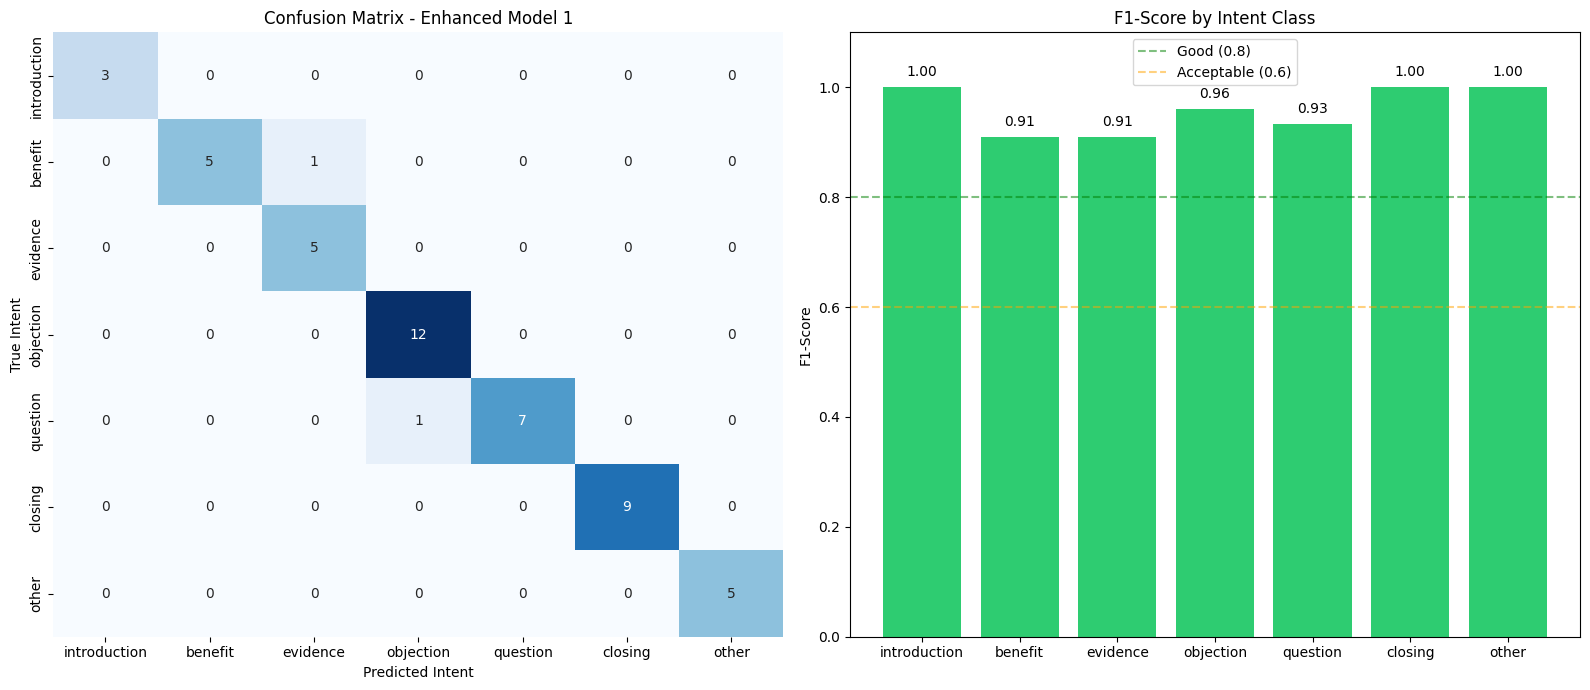

In [27]:
# ============================================================
# CELL 2: EVALUATION (run after the model cell above)
# Model1_LLM_RAG_Enhanced and load_products_cleaned
# are already in memory from Cell 1
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------------
# TEST SET: 48 Messages (Clean + Edge Cases)
# -------------------------------
test_set = [
    # === CLEAN / PROTOTYPICAL (20 messages) ===
    {"text": "Je vous presente notre nouveau serum anti-age", "true_intent": "introduction", "category": "clean"},
    {"text": "Aujourd'hui je vais vous parler de Ferbiotic", "true_intent": "introduction", "category": "clean"},
    {"text": "Let me introduce our new vitamin D supplement", "true_intent": "introduction", "category": "clean"},
    {"text": "Il aide a reduire la fatigue en 2 semaines", "true_intent": "benefit", "category": "clean"},
    {"text": "Ce produit hydrate intensivement la peau", "true_intent": "benefit", "category": "clean"},
    {"text": "It improves skin elasticity by 40%", "true_intent": "benefit", "category": "clean"},
    {"text": "Cette creme protege contre les UV et nourrit en profondeur", "true_intent": "benefit", "category": "clean"},
    {"text": "Une etude clinique de 500 patients le prouve", "true_intent": "evidence", "category": "clean"},
    {"text": "Selon le Lancet, l'efficacite est demontree", "true_intent": "evidence", "category": "clean"},
    {"text": "Clinical trial results show significant improvement", "true_intent": "evidence", "category": "clean"},
    {"text": "C'est trop cher compare a l'ancien produit", "true_intent": "objection", "category": "clean"},
    {"text": "Mes patients ont eu des effets secondaires", "true_intent": "objection", "category": "clean"},
    {"text": "Je ne suis pas sur de la tolerance cutanee", "true_intent": "objection", "category": "clean"},
    {"text": "The generic version is cheaper", "true_intent": "objection", "category": "clean"},
    {"text": "Quelle est la posologie exacte?", "true_intent": "question", "category": "clean"},
    {"text": "Est-ce compatible avec les anticoagulants?", "true_intent": "question", "category": "clean"},
    {"text": "How long should the treatment last?", "true_intent": "question", "category": "clean"},
    {"text": "Voulez-vous l'essayer avec vos patients?", "true_intent": "closing", "category": "clean"},
    {"text": "Puis-je vous laisser des echantillons?", "true_intent": "closing", "category": "clean"},
    {"text": "Shall we add this to your prescription list?", "true_intent": "closing", "category": "clean"},

    # === EDGE CASES / AMBIGUOUS (28 messages) ===
    {"text": "Are you sure this won't cause allergies?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Can you guarantee there are no interactions?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Is it really safe for pregnant women?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Why is this more expensive than the generic?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "How come the results are worse than amlodipine?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "Why should I switch when my current treatment works?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "This would really help your diabetic patients, don't you think?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "Your patients would love the results, shall we start?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "It fits perfectly with your practice, ready to try?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "The study looks good but I'm worried about liver toxicity what do you think?", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "Interesting benefits, though the price is concerning", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "My colleagues like it but I had a bad experience before", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "Ok...", "true_intent": "other", "category": "edge_short"},
    {"text": "Hmm, interesting", "true_intent": "other", "category": "edge_short"},
    {"text": "I see", "true_intent": "other", "category": "edge_short"},
    {"text": "Maybe", "true_intent": "other", "category": "edge_short"},
    {"text": "Not now", "true_intent": "other", "category": "edge_short"},
    {"text": "Le price est too high pour mes patients", "true_intent": "objection", "category": "edge_codeswitch"},
    {"text": "C'est trop expensive compare au generic", "true_intent": "objection", "category": "edge_codeswitch"},
    {"text": "When can we start the trial?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "Where do I sign for the samples?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "Who should I contact to order?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "A 2023 study in JAMA proves it reduces inflammation by 50%", "true_intent": "evidence", "category": "edge_evidence_benefit"},
    {"text": "Research from CHU Lyon shows superior hydration versus competitors", "true_intent": "evidence", "category": "edge_evidence_benefit"},
    {"text": "Patients report feeling more energetic after just one week", "true_intent": "benefit", "category": "edge_benefit_subtle"},
    {"text": "The skin looks visibly younger within 14 days", "true_intent": "benefit", "category": "edge_benefit_subtle"},
    {"text": "What happens if the patient misses a dose?", "true_intent": "question", "category": "edge_question_neutral"},
    {"text": "Do I need to monitor anything during treatment?", "true_intent": "question", "category": "edge_question_neutral"},
]

INTENT_LABELS = ["introduction", "benefit", "evidence", "objection", "question", "closing", "other"]


# -------------------------------
# EVALUATION FUNCTION
# -------------------------------
def evaluate_model(model, test_set, intent_labels, delay_between_calls=1.5):
    print("=" * 70)
    print(" MODEL 1 ENHANCED EVALUATION - INTENT CLASSIFICATION")
    print("=" * 70)

    clean_items = [t for t in test_set if t["category"] == "clean"]
    edge_items = [t for t in test_set if t["category"] != "clean"]
    print(f" Test set size: {len(test_set)} messages")
    print(f" Clean examples: {len(clean_items)} | Edge cases: {len(edge_items)}\n")

    y_true = []
    y_pred = []
    results_detail = []

    print("Running predictions...")
    for i, item in enumerate(test_set, 1):
        text = item["text"]
        true_intent = item["true_intent"]
        category = item.get("category", "unknown")

        result = model.analyze_message(text)
        pred_intent = result.get("intent", "other")
        llm_intent = result.get("llm_raw_intent", "unknown")

        y_true.append(true_intent)
        y_pred.append(pred_intent)

        match = "CORRECT" if pred_intent == true_intent else "FALSE"
        is_edge = " [EDGE]" if category != "clean" else ""
        results_detail.append({
            "msg": text[:55] + "..." if len(text) > 55 else text,
            "true": true_intent,
            "pred": pred_intent,
            "llm_raw": llm_intent,
            "match": match,
            "category": category
        })
        print(f"   {i:2d}.{is_edge} {match} True: {true_intent:15s} | Pred: {pred_intent:15s} | LLM: {llm_intent:15s} | {text[:40]}...")

        if i < len(test_set):
            time.sleep(delay_between_calls)

    # 1. OVERALL METRICS
    print(f"\n{'='*70}")
    print(" OVERALL METRICS")
    print(f"{'='*70}")

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', labels=intent_labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', labels=intent_labels, zero_division=0)

    print(f" Accuracy:      {accuracy:.2%}")
    print(f" Macro F1:      {macro_f1:.3f}")
    print(f" Weighted F1:   {weighted_f1:.3f}")

    # 2. CLEAN vs EDGE
    print(f"\n{'='*70}")
    print(" CLEAN vs EDGE CASE BREAKDOWN")
    print(f"{'='*70}")

    clean_correct = sum(1 for r in results_detail if r["match"] == "CORRECT" and r["category"] == "clean")
    edge_correct = sum(1 for r in results_detail if r["match"] == "CORRECT" and r["category"] != "clean")

    print(f" Clean set:          {clean_correct}/{len(clean_items)} = {clean_correct/len(clean_items):.1%}")
    print(f" Edge cases:         {edge_correct}/{len(edge_items)} = {edge_correct/len(edge_items):.1%}")

    # 3. EDGE SUBCATEGORIES
    print(f"\n{'='*70}")
    print(" EDGE CASE DETAIL (by subcategory)")
    print(f"{'='*70}")

    edge_categories = {}
    for r in results_detail:
        if r["category"] != "clean":
            cat = r["category"]
            if cat not in edge_categories:
                edge_categories[cat] = {"total": 0, "correct": 0}
            edge_categories[cat]["total"] += 1
            if r["match"] == "CORRECT":
                edge_categories[cat]["correct"] += 1

    for cat, stats in sorted(edge_categories.items()):
        acc = stats["correct"] / stats["total"] if stats["total"] > 0 else 0
        print(f"   {cat:35s}: {stats['correct']:2d}/{stats['total']:2d} = {acc:.1%}")

    # 4. PER-CLASS METRICS
    print(f"\n{'='*70}")
    print(" PER-CLASS METRICS")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, labels=intent_labels, digits=3, zero_division=0))

    # 5. CRITICAL INTENTS
    print(f"{'='*70}")
    print(" CRITICAL INTENT ANALYSIS")
    print(f"{'='*70}")

    for intent in ["objection", "closing", "other"]:
        true_binary = [1 if y == intent else 0 for y in y_true]
        pred_binary = [1 if y == intent else 0 for y in y_pred]
        rec = recall_score(true_binary, pred_binary, zero_division=0)
        prec = precision_score(true_binary, pred_binary, zero_division=0)
        f1 = f1_score(true_binary, pred_binary, zero_division=0)
        support = sum(true_binary)
        print(f"\n {intent.upper()}")
        print(f"   Precision: {prec:.2%}")
        print(f"   Recall:    {rec:.2%}")
        print(f"   F1-Score:  {f1:.3f}")
        print(f"   Support:   {support}")

    # 6. LLM vs POST-PROCESSING
    print(f"\n{'='*70}")
    print(" LLM vs POST-PROCESSING ANALYSIS")
    print(f"{'='*70}")

    llm_correct = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] == t)
    post_correct = sum(1 for r in results_detail if r["match"] == "CORRECT")
    overrides_helpful = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] != t and r["pred"] == t)
    overrides_harmful = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] == t and r["pred"] != t)

    print(f" LLM-only accuracy:      {llm_correct}/{len(test_set)} = {llm_correct/len(test_set):.1%}")
    print(f" With post-processing:   {post_correct}/{len(test_set)} = {post_correct/len(test_set):.1%}")
    print(f" Helpful overrides:      {overrides_helpful}")
    print(f" Harmful overrides:      {overrides_harmful}")

    # 7. CONFUSION MATRIX
    print(f"\n{'='*70}")
    print(" CONFUSION MATRIX")
    print(f"{'='*70}")

    cm = confusion_matrix(y_true, y_pred, labels=intent_labels)
    cm_df = pd.DataFrame(cm, index=intent_labels, columns=intent_labels)
    print(cm_df)

    # 8. ERROR ANALYSIS
    print(f"\n{'='*70}")
    print(" ERROR ANALYSIS")
    print(f"{'='*70}")

    errors = [r for r in results_detail if r["match"] == "FALSE"]
    if errors:
        print(f"Total errors: {len(errors)}/{len(test_set)}")
        clean_errors = [e for e in errors if e["category"] == "clean"]
        edge_errors = [e for e in errors if e["category"] != "clean"]

        if clean_errors:
            print(f"\nClean set errors:")
            for err in clean_errors:
                print(f"   - True: {err['true']:12s} | Pred: {err['pred']:12s} | LLM: {err['llm_raw']:12s} | {err['msg']}")

        if edge_errors:
            print(f"\nEdge case errors:")
            for err in edge_errors:
                print(f"   - True: {err['true']:12s} | Pred: {err['pred']:12s} | LLM: {err['llm_raw']:12s} | {err['msg']}")
    else:
        print(" Perfect score! No errors.")

    # 9. VISUALIZATION
    try:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
        axes[0].set_title('Confusion Matrix - Enhanced Model 1')
        axes[0].set_ylabel('True Intent')
        axes[0].set_xlabel('Predicted Intent')

        f1_scores = []
        for label in intent_labels:
            true_bin = [1 if y == label else 0 for y in y_true]
            pred_bin = [1 if y == label else 0 for y in y_pred]
            f1_scores.append(f1_score(true_bin, pred_bin, zero_division=0))

        colors = ['#2ecc71' if f >= 0.8 else '#f39c12' if f >= 0.6 else '#e74c3c' for f in f1_scores]
        axes[1].bar(intent_labels, f1_scores, color=colors)
        axes[1].set_title('F1-Score by Intent Class')
        axes[1].set_ylabel('F1-Score')
        axes[1].set_ylim(0, 1.1)
        axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good (0.8)')
        axes[1].axhline(y=0.6, color='orange', linestyle='--', alpha=0.5, label='Acceptable (0.6)')
        axes[1].legend()
        for i, v in enumerate(f1_scores):
            axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

        plt.tight_layout()
        plt.savefig('confusion_matrix_enhanced_v2.png', dpi=150)
        print(f"\n Visualization saved to confusion_matrix_enhanced_v2.png")
    except Exception as e:
        print(f"\n Could not plot: {e}")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "clean_accuracy": clean_correct / len(clean_items) if clean_items else 0,
        "edge_accuracy": edge_correct / len(edge_items) if edge_items else 0,
        "errors": len(errors),
        "total": len(test_set),
    }


# -------------------------------
# RUN
# -------------------------------
# Load products
product_info = load_products_cleaned("produits_final_complet.xlsx")

# Initialize model (already defined from Cell 1)
model1 = Model1_LLM_RAG_Enhanced(
    api_key=os.getenv("GROQ_API_KEY"),
    product_info=product_info
)

# Run evaluation
metrics = evaluate_model(model1, test_set, INTENT_LABELS, delay_between_calls=1.5)

print(f"\n{'='*70}")
print(" EVALUATION COMPLETE")
print(f"{'='*70}")
print(f"Overall:      Macro F1 = {metrics['macro_f1']:.3f}")
print(f"Clean set:    Accuracy = {metrics['clean_accuracy']:.1%}")
print(f"Edge cases:   Accuracy = {metrics['edge_accuracy']:.1%}")
print(f"Total errors: {metrics['errors']}/{metrics['total']}")

In [31]:
class DialogueStateTracker:
    def __init__(self):
        self.state = {
            "product": None,
            "claims_made": [],
            "evidence_shown": [],
            "objections": [],
            "questions_asked": [],
            "stage": "start",
            "turn_count": 0,
            "last_intent": None,
            "language": "en"
        }

    def update(self, model1_output):
        intent = model1_output.get("intent", "other")
        text = model1_output.get("text", "")
        product = model1_output.get("product")
        claims = model1_output.get("claims", [])
        language = model1_output.get("language", "en")

        # Update turn count
        self.state["turn_count"] += 1

        # Update product
        if product:
            self.state["product"] = product

        # Update language
        self.state["language"] = language

        # Update claims
        for claim in claims:
            if claim not in self.state["claims_made"]:
                self.state["claims_made"].append(claim)

        # Track intent
        self.state["last_intent"] = intent

        # Update stage
        self._update_stage(intent)

        # Track evidence
        if intent == "evidence":
            snippet = text[:100]
            if snippet not in self.state["evidence_shown"]:
                self.state["evidence_shown"].append(snippet)

        # Track objections
        elif intent == "objection":
            snippet = text[:100]
            if snippet not in self.state["objections"]:
                self.state["objections"].append(snippet)

        # Track questions
        elif intent == "question":
            snippet = text[:100]
            if snippet not in self.state["questions_asked"]:
                self.state["questions_asked"].append(snippet)

        return self.state

    def _update_stage(self, intent):
        current = self.state["stage"]

        if intent == "introduction":
            self.state["stage"] = "product_introduction"

        elif intent == "benefit" and current in ["start", "product_introduction"]:
            self.state["stage"] = "benefit_discussion"

        elif intent == "evidence":
            self.state["stage"] = "evidence_presentation"

        elif intent == "objection":
            self.state["stage"] = "objection_handling"

        elif intent == "closing":
            self.state["stage"] = "closing"

    def get_state(self):
        return self.state

    def reset(self):
        self.__init__()
        return self.state

In [32]:
# ============================================================
# PIPELINE TEST: Model 1 + Model 2 (Intent → State Tracking)
# Run this after both Model 1 and DialogueStateTracker are loaded
# ============================================================

tracker = DialogueStateTracker()

messages = [
    "Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss",
    "Calmoss aide à réduire le stress et améliore le sommeil",
    "Des études cliniques ont montré son efficacité chez les patients anxieux",
    "Est-ce qu'il y a un risque de dépendance ?",
    "Quelle est la posologie recommandée ?",
    "Pensez-vous le prescrire à vos patients ?"
]

print("=" * 70)
print(" PIPELINE TEST: Model 1 → Model 2")
print("=" * 70)

for msg in messages:
    # Step 1: Model 1 - Intent Classification
    model1_output = model1.analyze_message(msg)

    # Step 2: Model 2 - Dialogue State Tracking
    state = tracker.update(model1_output)

    print(f"\n{'─' * 60}")
    print(f"📝 Message: {msg}")
    print(f"🎯 Intent:  {model1_output['intent']}")
    print(f"📦 Product: {model1_output.get('product', 'N/A')}")
    print(f"🗣️  Language: {model1_output.get('language', 'N/A')}")
    print(f"📊 State:   {json.dumps(state, indent=2, ensure_ascii=False)}")

print(f"\n{'=' * 70}")
print(" FINAL STATE:")
print("=" * 70)
print(json.dumps(tracker.get_state(), indent=2, ensure_ascii=False))

 PIPELINE TEST: Model 1 → Model 2

────────────────────────────────────────────────────────────
📝 Message: Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss
🎯 Intent:  introduction
📦 Product: Vital Calmoss
🗣️  Language: fr
📊 State:   {
  "product": "Vital Calmoss",
  "claims_made": [],
  "evidence_shown": [],
  "objections": [],
  "questions_asked": [],
  "stage": "product_introduction",
  "turn_count": 1,
  "last_intent": "introduction",
  "language": "fr"
}

────────────────────────────────────────────────────────────
📝 Message: Calmoss aide à réduire le stress et améliore le sommeil
🎯 Intent:  benefit
📦 Product: None
🗣️  Language: fr
📊 State:   {
  "product": "Vital Calmoss",
  "claims_made": [],
  "evidence_shown": [],
  "objections": [],
  "questions_asked": [],
  "stage": "benefit_discussion",
  "turn_count": 2,
  "last_intent": "benefit",
  "language": "fr"
}

────────────────────────────────────────────────────────────
📝 Message: Des études cliniques ont montré 

In [33]:
pip install requests

In [ ]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.4 MB/s eta 0:00:00


In [40]:
"""
AVATAR DSO2 - Model 3: AI Doctor Response Generator + Metrics Tracker
Generates realistic doctor responses AND evaluates delegate performance
"""

import requests
import json
import re
import time
from groq import Groq
from dotenv import load_dotenv
load_dotenv()


class AIDoctorGenerator:
    def __init__(self, api_key):
        self.api_key = api_key
        self.api_url = "https://api.groq.com/openai/v1/chat/completions"

        # ===============================
        # PERSONAS (18 DOCTOR TYPES)
        # ===============================
        self.personas = {
            "dermatologist_aesthetic": {
                "name": "Dr. Leila",
                "specialty": "Dermatologue Esthetique",
                "personality": "Exigeante sur les actifs et concentrations. Veut voir les etudes d'efficacite in vivo."
            },
            "dermatologist_medical": {
                "name": "Dr. Karim",
                "specialty": "Dermatologue Medical",
                "personality": "Prudent avec les peaux sensibles et atopiques. Focus sur la tolerance et les allergenes."
            },
            "aesthetic_doctor": {
                "name": "Dr. Sophie",
                "specialty": "Medecin Esthetique",
                "personality": "Orientee resultats rapides. Interessee par les protocoles combines (creme + acte)."
            },
            "pharmacist_skincare": {
                "name": "Mme. Nadia",
                "specialty": "Pharmacienne Conseil",
                "personality": "Connait bien la concurrence (CeraVe, La Roche-Posay). Compare les prix et les compositions."
            },
            "pharmacist_supplements": {
                "name": "M. Ahmed",
                "specialty": "Pharmacien Nutrition",
                "personality": "Mefiant des allegations sante non validees. Verifie les certifications (ANSM, EFSA)."
            },
            "parapharmacist": {
                "name": "Mme. Yasmina",
                "specialty": "Conseillere Parapharmacie",
                "personality": "Proche des clients, connait les tendances (clean beauty, vegan). Oriente vers le 'best-seller'."
            },
            "general_practitioner": {
                "name": "Dr. Mohamed",
                "specialty": "Medecin Generaliste",
                "personality": "Pragmatique. Prescrit peu de cosmetiques mais recommande les complements pour carences."
            },
            "nutritionist": {
                "name": "Dr. Ines",
                "specialty": "Nutritionniste",
                "personality": "Analyse la biodisponibilite et les interactions alimentaires. Mefiante des 'superfoods'."
            },
            "naturopath": {
                "name": "Mme. Fatima",
                "specialty": "Naturopathe",
                "personality": "Favorable aux actifs naturels et plantes. Critique des conservateurs chimiques."
            },
            "endocrinologist": {
                "name": "Dr. Samira",
                "specialty": "Endocrinologue",
                "personality": "Interessee par les complements metaboliques (vitamine D, omega-3). Surveille les interactions."
            },
            "gastroenterologist": {
                "name": "Dr. Youssef",
                "specialty": "Gastro-enterologue",
                "personality": "Recommande les probiotiques cibles. Exige les souches documentees (CFU, souche specifique)."
            },
            "sports_doctor": {
                "name": "Dr. Djamel",
                "specialty": "Medecine du Sport",
                "personality": "Interesse par la recuperation musculaire et l'hydratation. Ouvert aux complements proteines."
            },
            "esthetician": {
                "name": "Mme. Aicha",
                "specialty": "Estheticienne",
                "personality": "Manuelle, connait les textures et les routines. Recommande ce qui 'fonctionne sur le client'."
            },
            "makeup_artist": {
                "name": "M. Karim",
                "specialty": "Maquilleur Pro",
                "personality": "Focus sur la tenue et la compatibilite maquillage. Veut des bases hydratantes non grasses."
            },
            "spa_director": {
                "name": "Mme. Lamia",
                "specialty": "Directrice de Spa",
                "personality": "Cherche l'experience client et les marges. Interessee par les protocoles 'rituels'."
            },
            "influencer": {
                "name": "Lina",
                "specialty": "Influenceuse Beaute",
                "personality": "Exigeante sur l'INCI, les avis clients, et l'emballage Instagrammable. Critique des greenwashing."
            },
            "patient_advocate": {
                "name": "Mme. Amel",
                "specialty": "Association de Patients (Acne)",
                "personality": "Defend les prix accessibles et les formules non comedogenes. Partage les retours de sa communaute."
            }
        }

        # ===============================
        # METRICS: KEYWORD SIGNALS
        # ===============================
        self.scientific_keywords = [
            "etude", "etude", "clinical", "clinique", "randomise", "randomized",
            "phase", "trial", "pubmed", "lancet", "jama", "nejm", "research",
            "recherche", "publication", "meta-analyse", "meta-analysis",
            "efficacite", "efficacy", "resultats", "results", "prouve", "proven",
            "data", "donnees", "p value", "statistically", "statistiquement",
            "pourcent", "percent", "%", "mg", "mcg", "ui", "cfu", "dosage",
            "posologie", "biodisponibilite", "bioavailability"
        ]

        self.objection_handling_keywords = [
            "comprendre", "understand", "je comprends", "i understand",
            "effectivement", "indeed", "c'est vrai", "that's true",
            "toutefois", "cependant", "however", "nevertheless",
            "mais", "but", "pourtant", "bien que",
            "soulevez un point", "raise a valid", "legitime", "legitimate",
            "etude montre", "study shows", "donnees prouvent", "data proves",
            "experience clinique", "clinical experience", "retour de",
            "feedback from", "cas similaire", "similar case"
        ]

        self.clarity_structures = [
            r"\bd'abord\b.*\bensuite\b.*\benfin\b",
            r"\bfirst\b.*\bthen\b.*\bfinally\b",
            r"\b1[.)]\b.*\b2[.)]\b",
            r"\bstep \d\b",
            r"\bpremierement\b.*\bdeuxiemement\b",
            r"\bfirstly\b.*\bsecondly\b",
        ]

        self.engagement_keywords = [
            "qu'en pensez-vous", "what do you think", "n'est-ce pas",
            "avez-vous deja", "have you ever",
            "avez-vous remarque", "have you noticed", "chez vos patients",
            "with your patients", "avez-vous observe", "have you observed",
            "comment trouvez-vous", "how do you find", "selon vous",
            "in your opinion", "pensez-vous", "do you think",
            "votre experience", "your experience"
        ]

        self.confidence_markers = [
            "je recommande", "i recommend", "nous savons que",
            "we know that", "il est etabli que", "it is established that",
            "les donnees montrent", "data shows", "l'evidence suggere",
            "evidence suggests", "je suis convaincu", "i am convinced",
            "resultats probants", "strong results", "efficacite prouvee",
            "proven efficacy", "recommande par", "recommended by"
        ]
        self.hesitant_markers = [
            "peut-etre", "maybe", "je ne suis pas sur", "i'm not sure",
            "euh", "uhm", "en fait", "actually", "je pense que",
            "i think", "probablement", "probably", "je crois",
            "i believe", "normalement", "normally", "si vous voulez",
            "if you want", "si ca vous convient", "if it suits you"
        ]

    # ===============================
    # DOCTOR RESPONSE GENERATION
    # ===============================
    def generate_response(self, delegate_text, dialogue_state, persona="general_practitioner"):
        persona_info = self.personas.get(persona, self.personas["general_practitioner"])
        language = dialogue_state.get("language", "en")
        product = dialogue_state.get("product", "ce produit")
        stage = dialogue_state.get("stage", "start")

        if language == "fr":
            prompt = (
                f"Tu es {persona_info['name']}, {persona_info['specialty']}.\n"
                f"{persona_info['personality']}\n\n"
                f"Delegue: '{delegate_text}'\n"
                f"Produit discute: {product}\n"
                f"Etape: {stage}\n\n"
                f"Reponds de maniere naturelle, concise (1-2 phrases)."
            )
        else:
            prompt = (
                f"You are {persona_info['name']}, a {persona_info['specialty']}.\n"
                f"{persona_info['personality']}\n\n"
                f"Delegate: '{delegate_text}'\n"
                f"Product: {product}\n"
                f"Stage: {stage}\n\n"
                f"Respond naturally in 1-2 sentences."
            )

        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        payload = {
            "model": "llama-3.1-8b-instant",
            "messages": [
                {"role": "system", "content": "You are a helpful medical assistant."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0.7,
            "max_tokens": 150
        }

        try:
            response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)
            if response.status_code == 200:
                result = response.json()
                reply = result["choices"][0]["message"]["content"]
            elif response.status_code == 429:
                time.sleep(2)
                response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)
                if response.status_code == 200:
                    result = response.json()
                    reply = result["choices"][0]["message"]["content"]
                else:
                    reply = f"[API Error {response.status_code}]"
            else:
                reply = f"[API Error {response.status_code}]"
        except Exception:
            reply = "[API Timeout/Error]"

        return reply[:200]

    # ===============================
    # METRICS: EVALUATE DELEGATE MESSAGE
    # ===============================
    def evaluate_metrics(self, delegate_text, model1_output, dialogue_state):
        text_lower = delegate_text.lower()
        intent = model1_output.get("intent", "other")
        previous_intent = dialogue_state.get("last_intent", "start")
        objections_raised = dialogue_state.get("objections", [])
        turn_count = dialogue_state.get("turn_count", 0)

        # --- 1. SCIENTIFIC ACCURACY ---
        sci_matches = sum(1 for kw in self.scientific_keywords if kw in text_lower)

        if intent in ["introduction", "closing"]:
            sci_score = 40
        elif intent == "evidence":
            sci_score = min(50 + sci_matches * 10, 95)
        elif sci_matches >= 2:
            sci_score = min(30 + sci_matches * 8, 75)
        elif sci_matches >= 1:
            sci_score = 25
        else:
            sci_score = 15

        # --- 2. OBJECTION HANDLING (FULLY FIXED) ---
        if turn_count <= 1 or len(objections_raised) == 0:
            obj_score = 50
        elif previous_intent == "objection" and intent in ["benefit", "evidence"]:
            # Good: actively addressing the objection with data/benefits
            obj_matches = sum(1 for kw in self.objection_handling_keywords if kw in text_lower)
            if obj_matches >= 3:
                obj_score = 90
            elif obj_matches >= 1:
                obj_score = 65
            else:
                obj_score = 45
        elif intent == "closing" and len(objections_raised) > 0:
            # Bad: trying to close while objections are still unresolved
            obj_score = max(20, 40 - len(objections_raised) * 10)
        elif previous_intent == "objection" and intent in ["question", "objection"]:
            # Dodging the objection or stuck on it
            obj_score = 30
        else:
            # Objections exist but this turn doesn't address them
            obj_score = max(35, 55 - len(objections_raised) * 10)

        # --- 3. COMMUNICATION CLARITY ---
        clarity_score = 50
        word_count = len(delegate_text.split())
        if 5 <= word_count <= 40:
            clarity_score += 20
        elif word_count > 40:
            clarity_score += 5
        elif word_count < 5:
            clarity_score -= 15

        for pattern in self.clarity_structures:
            if re.search(pattern, text_lower):
                clarity_score += 15
                break

        filler_count = text_lower.count("euh") + text_lower.count("uhm") + text_lower.count("hum")
        clarity_score -= filler_count * 5
        clarity_score = max(0, min(100, clarity_score))

        # --- 4. ENGAGEMENT ---
        eng_score = 30
        eng_matches = sum(1 for kw in self.engagement_keywords if kw in text_lower)
        eng_score += eng_matches * 12

        if intent == "closing":
            eng_score += 15
        if intent == "question":
            eng_score += 10
        if turn_count <= 1:
            eng_score = max(eng_score, 40)

        eng_score = min(100, eng_score)

        # --- 5. CONFIDENCE ---
        conf_score = 50
        confident_matches = sum(1 for kw in self.confidence_markers if kw in text_lower)
        hesitant_matches = sum(1 for kw in self.hesitant_markers if kw in text_lower)

        conf_score += confident_matches * 12
        conf_score -= hesitant_matches * 8

        if text_lower.endswith("?") and intent == "closing":
            conf_score -= 5
        if "!" in delegate_text and confident_matches >= 1:
            conf_score += 5

        conf_score = max(10, min(100, conf_score))

        # --- COMPILED METRICS ---
        metrics = {
            "scientific_accuracy": round(sci_score, 1),
            "objection_handling": round(obj_score, 1),
            "communication_clarity": round(clarity_score, 1),
            "engagement": round(eng_score, 1),
            "confidence": round(conf_score, 1),
            "overall_score": round((sci_score + obj_score + clarity_score + eng_score + conf_score) / 5, 1)
        }

        # --- FEEDBACK PER DIMENSION ---
        feedback = []

        if sci_score >= 80:
            feedback.append("Excellent use of clinical data and scientific terminology.")
        elif sci_score >= 60:
            feedback.append("Good scientific grounding. Could add more specific study references.")
        elif sci_score >= 40:
            feedback.append("Limited scientific backing. Mention studies, dosages, or clinical data.")
        else:
            feedback.append("No scientific evidence presented. Doctors need data to trust claims.")

        if obj_score >= 80:
            feedback.append("Excellent objection handling: acknowledged concern and provided counter-evidence.")
        elif obj_score >= 60:
            feedback.append("Good response to objection. Try acknowledging the doctor's concern more explicitly.")
        elif obj_score >= 40:
            feedback.append("Partial objection handling. Use 'I understand, however...' structure.")
        elif previous_intent == "objection" and obj_score < 40:
            feedback.append("Objection dodged or unresolved. Always acknowledge concerns before moving on.")
        else:
            feedback.append("Objection handling opportunity missed. Prepare evidence-based counter-arguments.")

        if clarity_score >= 80:
            feedback.append("Very clear and well-structured message.")
        elif clarity_score >= 60:
            feedback.append("Message is understandable. Avoid fillers and structure your points.")
        else:
            feedback.append("Message unclear or too brief/verbose. Use structured arguments.")

        if eng_score >= 80:
            feedback.append("Highly engaging: good use of questions and doctor involvement.")
        elif eng_score >= 60:
            feedback.append("Moderate engagement. Ask for the doctor's opinion or experience.")
        else:
            feedback.append("Low engagement. Turn monologue into dialogue.")

        if conf_score >= 80:
            feedback.append("Confident and assertive delivery.")
        elif conf_score >= 60:
            feedback.append("Reasonably confident. Reduce filler words and hesitant language.")
        else:
            feedback.append("Appears uncertain. Use evidence-based statements instead of 'maybe/I think'.")

        metrics["feedback"] = feedback

        # --- ACCUMULATE IN STATE ---
        if "metrics_history" not in dialogue_state:
            dialogue_state["metrics_history"] = []
        dialogue_state["metrics_history"].append({
            "turn": turn_count,
            "message": delegate_text[:80],
            **metrics
        })

        # Running averages
        history = dialogue_state["metrics_history"]
        dialogue_state["avg_scientific_accuracy"] = round(sum(m["scientific_accuracy"] for m in history) / len(history), 1)
        dialogue_state["avg_objection_handling"] = round(sum(m["objection_handling"] for m in history) / len(history), 1)
        dialogue_state["avg_communication_clarity"] = round(sum(m["communication_clarity"] for m in history) / len(history), 1)
        dialogue_state["avg_engagement"] = round(sum(m["engagement"] for m in history) / len(history), 1)
        dialogue_state["avg_confidence"] = round(sum(m["confidence"] for m in history) / len(history), 1)
        dialogue_state["avg_overall_score"] = round(sum(m["overall_score"] for m in history) / len(history), 1)

        # Identify weakest/strongest skill for Model 5
        dimensions = {
            "scientific_accuracy": dialogue_state["avg_scientific_accuracy"],
            "objection_handling": dialogue_state["avg_objection_handling"],
            "communication_clarity": dialogue_state["avg_communication_clarity"],
            "engagement": dialogue_state["avg_engagement"],
            "confidence": dialogue_state["avg_confidence"]
        }
        dialogue_state["weakest_skill"] = min(dimensions, key=dimensions.get)
        dialogue_state["strongest_skill"] = max(dimensions, key=dimensions.get)

        return metrics


# ===============================
# PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)
# ===============================

if __name__ == "__main__":

    # Initialize Model 2 (Dialogue State Tracker)
    tracker = DialogueStateTracker()

    # Initialize Model 3 (Doctor + Metrics)
    doctor = AIDoctorGenerator(api_key=os.getenv("GROQ_API_KEY"))

    messages = [
        "Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss",
        "Calmoss aide a reduire le stress et ameliore le sommeil",
        "Des etudes cliniques ont montre son efficacite chez les patients anxieux",
        "Pensez-vous le prescrire a vos patients ?"
    ]

    print("=" * 70)
    print(" PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)")
    print("=" * 70)

    for msg in messages:
        # Step 1: Model 1 - Intent Classification
        m1_out = model1.analyze_message(msg)

        # Step 2: Model 2 - Dialogue State Tracking
        state = tracker.update(m1_out)

        # Step 3: Model 3a - Doctor Response
        response = doctor.generate_response(msg, state, persona="general_practitioner")

        # Step 3b: Model 3b - Metrics Evaluation
        metrics = doctor.evaluate_metrics(msg, m1_out, state)

        print(f"\n{'─' * 60}")
        print(f"📝 Delegate: {msg}")
        print(f"🎯 Intent:   {m1_out['intent']}")
        print(f"👨‍⚕️ Doctor:   {response}")
        print(f"📊 Metrics:  {json.dumps({k: v for k, v in metrics.items() if k != 'feedback'}, indent=2, ensure_ascii=False)}")

    # Final Summary
    print(f"\n{'=' * 70}")
    print(" SESSION METRICS SUMMARY")
    print(f"{'=' * 70}")
    final_state = tracker.get_state()
    print(f"Turns:              {final_state.get('turn_count', 0)}")
    print(f"Product:            {final_state.get('product', 'N/A')}")
    print(f"Stage:              {final_state.get('stage', 'N/A')}")
    print(f"Overall Score:      {final_state.get('avg_overall_score', 0)}/100")
    print(f"Scientific Acc:     {final_state.get('avg_scientific_accuracy', 0)}/100")
    print(f"Objection Handling: {final_state.get('avg_objection_handling', 0)}/100")
    print(f"Communication:      {final_state.get('avg_communication_clarity', 0)}/100")
    print(f"Engagement:         {final_state.get('avg_engagement', 0)}/100")
    print(f"Confidence:         {final_state.get('avg_confidence', 0)}/100")
    print(f"Strongest Skill:    {final_state.get('strongest_skill', 'N/A')}")
    print(f"Weakest Skill:      {final_state.get('weakest_skill', 'N/A')} -> feeds into Model 5 recommendations")

 PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)

────────────────────────────────────────────────────────────
📝 Delegate: Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss
🎯 Intent:   introduction
👨‍⚕️ Doctor:   Vital Calmoss, c'est déjà un nom que je connais. Il s'agit d'un complément alimentaire destiné à soutenir l'équilibre hormonal et la gestion du stress, n'est-ce pas ?
📊 Metrics:  {
  "scientific_accuracy": 40,
  "objection_handling": 50,
  "communication_clarity": 70,
  "engagement": 40,
  "confidence": 50,
  "overall_score": 50.0
}

────────────────────────────────────────────────────────────
📝 Delegate: Calmoss aide a reduire le stress et ameliore le sommeil
🎯 Intent:   benefit
👨‍⚕️ Doctor:   Oui, j'ai lu le profil du Vital Calmoss. Il peut aider à réduire les niveaux de cortisol et à améliorer la qualité du sommeil, ce qui est essentiel pour la santé globale.
📊 Metrics:  {
  "scientific_accuracy": 25,
  "objection_handling": 50,
  "communication

In [41]:
# ===============================
# MODEL 4: Performance Scoring Model (IMPROVED with Semantic Similarity)
# ===============================

from sentence_transformers import SentenceTransformer, util

class PerformanceScorer:
    def __init__(self, product_catalog, product_details=None, wiki_claims=None, pubmed_claims=None):
        """
        Initialize scorer with semantic similarity model
        """
        self.products = [p.lower() for p in product_catalog]
        self.product_details = product_details or {}

        # 🔥 Load embedding model (only once)
        self.model = SentenceTransformer('all-MiniLM-L6-v2')

        # Build medical knowledge base
        self.medical_claims = []

        if product_details:
            for product, details in product_details.items():
                indication = details.get("indication", "")
                if indication:
                    self.medical_claims.append(indication)

        if wiki_claims:
            self.medical_claims.extend(wiki_claims)

        if pubmed_claims:
            self.medical_claims.extend(pubmed_claims)

        # Precompute embeddings (OPTIMIZATION 🚀)
        if self.medical_claims:
            self.medical_embeddings = self.model.encode(self.medical_claims, convert_to_tensor=True)
        else:
            self.medical_embeddings = None

        # Weights
        self.weights = {
            "accuracy": 0.4,
            "product_knowledge": 0.3,
            "evidence_usage": 0.2,
            "objection_handling": 0.1
        }

    # -------------------------------
    # 🔹 SEMANTIC SIMILARITY FUNCTION
    # -------------------------------
    def is_similar(self, claim, threshold=0.6):
        if not self.medical_claims:
            return False

        claim_emb = self.model.encode(claim, convert_to_tensor=True)
        scores = util.cos_sim(claim_emb, self.medical_embeddings)

        return scores.max().item() > threshold

    # -------------------------------
    # 🔹 ACCURACY SCORE (FIXED 🔥)
    # -------------------------------
    def score_claim_accuracy(self, claims):
        if not claims:
            return 0

        matches = 0

        for claim in claims:
            if self.is_similar(claim):
                matches += 1

        return round(100 * matches / len(claims))

    # -------------------------------
    # 🔹 PRODUCT KNOWLEDGE (IMPROVED)
    # -------------------------------
    def score_product_knowledge(self, claims, product_name=None):
        if not claims:
            return 0

        if product_name and product_name in self.product_details:
            indication = self.product_details[product_name].get("indication", "")

            if indication:
                indication_emb = self.model.encode(indication, convert_to_tensor=True)

                relevant = 0
                for claim in claims:
                    claim_emb = self.model.encode(claim, convert_to_tensor=True)
                    score = util.cos_sim(claim_emb, indication_emb).item()

                    if score > 0.5:
                        relevant += 1

                return round(100 * relevant / len(claims))

        return 0

    # -------------------------------
    def score_evidence_usage(self, evidence_list):
        if not evidence_list:
            return 0
        return min(len(evidence_list) * 20, 100)

    # -------------------------------
    def score_objection_handling(self, objections_raised, objections_handled):
        if not objections_raised:
            return 100
        if not objections_handled:
            return 0
        return round(100 * len(objections_handled) / len(objections_raised))

    # -------------------------------
    # 🔹 FINAL EVALUATION
    # -------------------------------
    def evaluate(self, dialogue_state):

        claims = dialogue_state.get("claims_made", [])
        evidence = dialogue_state.get("evidence_shown", [])
        objections_raised = dialogue_state.get("objections", [])
        objections_handled = dialogue_state.get("objections_handled", [])
        product_name = dialogue_state.get("product", None)

        accuracy_score = self.score_claim_accuracy(claims)
        product_score = self.score_product_knowledge(claims, product_name)
        evidence_score = self.score_evidence_usage(evidence)
        objection_score = self.score_objection_handling(objections_raised, objections_handled)

        final_score = (
            accuracy_score * self.weights["accuracy"] +
            product_score * self.weights["product_knowledge"] +
            evidence_score * self.weights["evidence_usage"] +
            objection_score * self.weights["objection_handling"]
        )

        # Level
        if final_score >= 85:
            level = "Expert"
        elif final_score >= 70:
            level = "Proficient"
        elif final_score >= 50:
            level = "Intermediate"
        else:
            level = "Beginner"

        # Feedback
        feedback = []
        if accuracy_score < 70:
            feedback.append("Use more scientifically valid claims.")
        if product_score < 70:
            feedback.append("Improve product-specific arguments.")
        if evidence_score < 50:
            feedback.append("Add more clinical evidence.")
        if objection_score < 70:
            feedback.append("Handle objections better.")

        return {
            "final_score": round(final_score, 1),
            "level": level,
            "accuracy_score": accuracy_score,
            "product_knowledge_score": product_score,
            "evidence_score": evidence_score,
            "objection_score": objection_score,
            "feedback": " ".join(feedback) if feedback else "Good job!",
            "language": dialogue_state.get("language", "fr")
        }


# ===============================
# ✅ TEST
# ===============================
if __name__ == "__main__":

    product_info = {
        "CALMOSS": {
            "indication": "Soulagement du stress et de l'anxiété"
        }
    }

    scorer = PerformanceScorer(
        product_catalog=["CALMOSS"],
        product_details=product_info,
        wiki_claims=[
            "réduit le stress",
            "améliore le sommeil",
            "réduit l'anxiété"
        ]
    )

    dialogue_state = {
        "product": "CALMOSS",
        "claims_made": ["réduit le stress", "améliore le sommeil"],
        "evidence_shown": ["Une étude clinique montre son efficacité"],
        "objections": ["Est-ce qu’il y a un risque de dépendance ?"],
        "objections_handled": [],
        "language": "fr"
    }

    result = scorer.evaluate(dialogue_state)

    print("\nRESULT:")
    for k, v in result.items():
        print(k, ":", v)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


RESULT:
final_score : 59.0
level : Intermediate
accuracy_score : 100
product_knowledge_score : 50
evidence_score : 20
objection_score : 0
feedback : Improve product-specific arguments. Add more clinical evidence. Handle objections better.
language : fr


In [43]:
# ===============================
# MODEL 5: Adaptive Learning Recommendation Model
# ===============================

import json
import numpy as np
import pandas as pd
from collections import defaultdict
import random
from typing import Dict, List, Tuple, Optional

# -------------------------------
# 1. LEARNING MODULE CATALOG
# -------------------------------

LEARNING_MODULES = {
    "product_knowledge": {
        "name": "Product Knowledge Mastery",
        "description": "Learn product composition, indications, dosage, and positioning",
        "difficulty": "beginner",
        "category": "knowledge",
        "estimated_time": 45,
        "prerequisites": []
    },
    "clinical_evidence": {
        "name": "Clinical Evidence & Studies",
        "description": "Review clinical trials, efficacy data, and scientific publications",
        "difficulty": "intermediate",
        "category": "knowledge",
        "estimated_time": 60,
        "prerequisites": ["product_knowledge"]
    },
    "objection_handling": {
        "name": "Objection Handling Techniques",
        "description": "Learn to address common doctor concerns about safety, efficacy, and cost",
        "difficulty": "intermediate",
        "category": "skills",
        "estimated_time": 50,
        "prerequisites": ["product_knowledge"]
    },
    "benefit_statement": {
        "name": "Benefits Communication",
        "description": "Master articulating product benefits clearly and persuasively",
        "difficulty": "beginner",
        "category": "skills",
        "estimated_time": 40,
        "prerequisites": []
    },
    "scientific_accuracy": {
        "name": "Scientific Communication",
        "description": "Improve scientific terminology and accurate claim presentation",
        "difficulty": "advanced",
        "category": "skills",
        "estimated_time": 55,
        "prerequisites": ["clinical_evidence"]
    },
    "question_techniques": {
        "name": "Effective Questioning",
        "description": "Learn to ask probing questions to uncover doctor needs",
        "difficulty": "intermediate",
        "category": "skills",
        "estimated_time": 35,
        "prerequisites": []
    },
    "closing_techniques": {
        "name": "Closing Strategies",
        "description": "Master techniques to secure commitment and next steps",
        "difficulty": "advanced",
        "category": "skills",
        "estimated_time": 45,
        "prerequisites": ["objection_handling"]
    },
    "communication_clarity": {
        "name": "Communication Clarity",
        "description": "Enhance message clarity, conciseness, and impact",
        "difficulty": "beginner",
        "category": "soft_skills",
        "estimated_time": 30,
        "prerequisites": []
    },
    "engagement_techniques": {
        "name": "Engagement Strategies",
        "description": "Techniques to maintain doctor engagement throughout the conversation",
        "difficulty": "intermediate",
        "category": "soft_skills",
        "estimated_time": 40,
        "prerequisites": ["communication_clarity"]
    },
    "confidence_building": {
        "name": "Confidence Building",
        "description": "Develop presence, assertiveness, and confident delivery",
        "difficulty": "advanced",
        "category": "soft_skills",
        "estimated_time": 50,
        "prerequisites": ["objection_handling", "communication_clarity"]
    },
    "role_play_scenarios": {
        "name": "Role-Play Scenarios",
        "description": "Practice with realistic doctor personas and challenging situations",
        "difficulty": "intermediate",
        "category": "practice",
        "estimated_time": 90,
        "prerequisites": ["product_knowledge", "objection_handling"]
    }
}

# -------------------------------
# 2. RECOMMENDATION STRATEGIES
# -------------------------------

class AdaptiveLearningRecommender:

    def __init__(self, learning_modules: Dict = None):
        self.modules = learning_modules or LEARNING_MODULES
        self.user_history = defaultdict(list)
        self.user_performance = defaultdict(dict)
        self.module_popularity = defaultdict(int)
        self.exploration_rate = 0.3

    def _map_performance_to_weaknesses(self, performance_score: Dict) -> List[str]:
        """
        Map performance scores to specific weaknesses
        """
        weaknesses = []

        if performance_score.get("product_knowledge_score", 100) < 70:
            weaknesses.append("product_knowledge")

        if performance_score.get("accuracy_score", 100) < 70:
            weaknesses.append("scientific_accuracy")

        if performance_score.get("evidence_score", 100) < 60:
            weaknesses.append("clinical_evidence")

        if performance_score.get("objection_score", 100) < 70:
            weaknesses.append("objection_handling")

        # Check feedback for additional insights
        feedback = performance_score.get("feedback", "").lower()
        if "preuves" in feedback or "etudes" in feedback or "etude" in feedback:
            weaknesses.append("clinical_evidence")
        if "connaissance" in feedback or "produits" in feedback:
            weaknesses.append("product_knowledge")
        if "preoccupations" in feedback or "inquiet" in feedback:
            weaknesses.append("objection_handling")

        # If no specific weaknesses, recommend improvement modules
        if not weaknesses:
            weaknesses = ["communication_clarity", "engagement_techniques"]

        # REMOVE DUPLICATES while preserving order
        seen = set()
        unique_weaknesses = []
        for w in weaknesses:
            if w not in seen:
                seen.add(w)
                unique_weaknesses.append(w)

        return unique_weaknesses

    def _analyze_intent_patterns(self, dialogue_state: Dict) -> Dict:
        """
        Analyze intent patterns to identify skill gaps
        """
        intents = dialogue_state.get("intent_history", [])

        if not intents:
            return {}

        intent_counts = defaultdict(int)
        for intent in intents:
            intent_counts[intent] += 1

        analysis = {
            "has_introduction": intent_counts.get("introduction", 0) > 0,
            "has_benefits": intent_counts.get("benefit", 0) > 0,
            "has_evidence": intent_counts.get("evidence", 0) > 0,
            "has_objection_handling": intent_counts.get("objection", 0) > 0,
            "has_question": intent_counts.get("question", 0) > 0,
            "has_closing": intent_counts.get("closing", 0) > 0,
        }

        missing = []
        if not analysis["has_benefits"]:
            missing.append("benefit_statement")
        if not analysis["has_evidence"]:
            missing.append("clinical_evidence")
        if not analysis["has_objection_handling"] and intent_counts.get("objection", 0) > 0:
            missing.append("objection_handling")
        if not analysis["has_closing"]:
            missing.append("closing_techniques")

        return {"missing_skills": missing, "intent_distribution": dict(intent_counts)}

    def _collaborative_filtering(self, user_id: str, k: int = 3) -> List[str]:
        """
        Find similar users and recommend what they liked
        """
        if user_id not in self.user_history or len(self.user_history) < 2:
            return []

        user_modules = set(self.user_history[user_id])

        similar_users = []
        for other_user, modules in self.user_history.items():
            if other_user == user_id:
                continue
            overlap = len(user_modules.intersection(modules))
            if overlap > 0:
                similar_users.append((other_user, overlap))

        similar_users.sort(key=lambda x: x[1], reverse=True)

        recommendations = []
        for other_user, _ in similar_users[:k]:
            for module in self.user_history[other_user]:
                if module not in user_modules and module not in recommendations:
                    recommendations.append(module)

        return recommendations[:3]

    def _multi_armed_bandit(self, candidates: List[str], user_id: str) -> str:
        """
        Use epsilon-greedy strategy for exploration/exploitation
        """
        if random.random() < self.exploration_rate:
            return random.choice(candidates)

        best_module = None
        best_score = -float('inf')

        for module in candidates:
            popularity_score = self.module_popularity[module] / (max(1, len(self.user_history)))
            recency_bonus = 0.1 if module not in self.user_history[user_id] else 0
            score = popularity_score + recency_bonus

            if score > best_score:
                best_score = score
                best_module = module

        return best_module

    def _generate_learning_path(self, weaknesses: List[str], difficulty_pref: str = None) -> List[str]:
        """
        Generate a coherent learning path based on prerequisites
        """
        target_modules = []
        for weakness in weaknesses:
            if weakness in self.modules:
                target_modules.append(weakness)

        learning_path = []
        completed = set()

        def add_with_prerequisites(module_id):
            if module_id in completed:
                return

            module = self.modules.get(module_id, {})
            prerequisites = module.get("prerequisites", [])

            for prereq in prerequisites:
                if prereq not in completed:
                    add_with_prerequisites(prereq)

            if module_id not in learning_path:
                learning_path.append(module_id)
            completed.add(module_id)

        for module in target_modules:
            add_with_prerequisites(module)

        if difficulty_pref:
            filtered_path = []
            for module_id in learning_path:
                module = self.modules.get(module_id, {})
                if module.get("difficulty") == difficulty_pref:
                    filtered_path.append(module_id)
            return filtered_path if filtered_path else learning_path

        return learning_path

    def recommend(self,
                  user_id: str,
                  performance_score: Dict,
                  dialogue_state: Dict,
                  previous_recommendations: List[str] = None,
                  n_recommendations: int = 3) -> Dict:
        """
        Generate personalized learning recommendations
        """
        # 1. Rule-based: Map performance to weaknesses
        weaknesses = self._map_performance_to_weaknesses(performance_score)

        # 2. Analyze conversation patterns
        intent_analysis = self._analyze_intent_patterns(dialogue_state)
        weaknesses.extend(intent_analysis.get("missing_skills", []))

        # 3. Collaborative filtering
        collaborative_recs = self._collaborative_filtering(user_id)

        # 4. Generate learning path
        learning_path = self._generate_learning_path(weaknesses)

        # 5. Combine recommendations
        candidates = list(set(learning_path + collaborative_recs))

        # Remove already completed modules
        completed = self.user_history.get(user_id, [])
        candidates = [c for c in candidates if c not in completed]

        # Remove previous recommendations if already suggested
        if previous_recommendations:
            candidates = [c for c in candidates if c not in previous_recommendations]

        # 6. Use multi-armed bandit for selection
        final_recommendations = []
        for _ in range(min(n_recommendations, len(candidates))):
            selected = self._multi_armed_bandit(candidates, user_id)
            if selected:
                final_recommendations.append(selected)
                candidates.remove(selected)

        # 7. If not enough recommendations, add default modules
        if len(final_recommendations) < n_recommendations:
            default_modules = ["communication_clarity", "product_knowledge", "role_play_scenarios"]
            for module in default_modules:
                if module not in final_recommendations and module not in completed:
                    final_recommendations.append(module)
                    if len(final_recommendations) >= n_recommendations:
                        break

        # 8. Build response with module details
        recommendations = []
        for module_id in final_recommendations:
            module = self.modules.get(module_id, {
                "name": module_id.replace("_", " ").title(),
                "description": "Module description",
                "difficulty": "intermediate",
                "estimated_time": 45
            })

            recommendations.append({
                "id": module_id,
                "name": module.get("name"),
                "description": module.get("description"),
                "difficulty": module.get("difficulty"),
                "estimated_time": module.get("estimated_time"),
                "reason": self._get_recommendation_reason(module_id, weaknesses, performance_score)
            })

        return {
            "user_id": user_id,
            "recommendations": recommendations,
            "weaknesses_identified": weaknesses,
            "skill_gaps": intent_analysis.get("missing_skills", []),
            "performance_summary": {
                "score": performance_score.get("final_score"),
                "level": performance_score.get("level")
            },
            "learning_path_complexity": "advanced" if len(learning_path) > 3 else "standard",
            "estimated_total_time": sum(m.get("estimated_time", 0) for m in recommendations)
        }

    def _get_recommendation_reason(self, module_id: str, weaknesses: List[str], performance: Dict) -> str:
        """
        Generate human-readable reason for recommendation
        """
        reasons = {
            "product_knowledge": "Your product knowledge score was low. Improve understanding of product details.",
            "clinical_evidence": "You need to cite more clinical studies and scientific evidence.",
            "objection_handling": "Improve your ability to address doctor concerns effectively.",
            "scientific_accuracy": "Enhance scientific accuracy in your claims and terminology.",
            "benefit_statement": "Develop clearer and more persuasive benefit statements.",
            "closing_techniques": "Practice closing techniques to secure commitments.",
            "communication_clarity": "Improve clarity and conciseness in your communication.",
            "engagement_techniques": "Learn strategies to maintain doctor engagement.",
            "confidence_building": "Build confidence in your delivery and presence.",
            "role_play_scenarios": "Practice with realistic scenarios to reinforce your skills."
        }

        if module_id in reasons:
            return reasons[module_id]
        return f"Recommended based on your performance in {module_id.replace('_', ' ')}."

    def update_user_progress(self, user_id: str, completed_module: str, module_score: float = None):
        """
        Update user's learning history after completing a module
        """
        if user_id not in self.user_history:
            self.user_history[user_id] = []

        if completed_module not in self.user_history[user_id]:
            self.user_history[user_id].append(completed_module)
            self.module_popularity[completed_module] += 1

        if module_score and user_id in self.user_performance:
            self.user_performance[user_id][completed_module] = module_score

    def get_next_learning_objective(self, user_id: str, performance_score: Dict) -> Dict:
        """
        Get the single most important next learning objective
        """
        recommendations = self.recommend(user_id, performance_score, {}, n_recommendations=1)

        if recommendations["recommendations"]:
            top_rec = recommendations["recommendations"][0]
            return {
                "priority": "high",
                "objective": top_rec["name"],
                "reason": top_rec["reason"],
                "estimated_time": top_rec["estimated_time"],
                "difficulty": top_rec["difficulty"]
            }

        return {
            "priority": "medium",
            "objective": "General Practice",
            "reason": "Continue practicing with various scenarios",
            "estimated_time": 30,
            "difficulty": "intermediate"
        }


# -------------------------------
# 3. INTEGRATION WITH EXISTING PIPELINE
# -------------------------------

class LearningRecommendationPipeline:

    def __init__(self):
        self.recommender = AdaptiveLearningRecommender()
        self.session_history = defaultdict(list)

    def process_complete_session(self,
                                  user_id: str,
                                  messages: List[str],
                                  models_1_4_outputs: Dict) -> Dict:
        """
        Process a complete conversation session through all models
        """
        performance = models_1_4_outputs.get("performance", {})
        dialogue_state = models_1_4_outputs.get("dialogue_state", {})

        recommendations = self.recommender.recommend(
            user_id=user_id,
            performance_score=performance,
            dialogue_state=dialogue_state
        )

        self.session_history[user_id].append({
            "timestamp": pd.Timestamp.now(),
            "performance": performance,
            "recommendations": recommendations
        })

        return recommendations

    def adaptive_learning_loop(self, user_id: str, max_iterations: int = 5) -> List[Dict]:
        """
        Simulate adaptive learning loop where user improves over time
        """
        learning_path = []
        current_performance = {"final_score": 50, "level": "Beginner"}

        for i in range(max_iterations):
            # Get recommendations based on current performance
            recs = self.recommender.recommend(
                user_id=user_id,
                performance_score=current_performance,
                dialogue_state={},
                n_recommendations=3
            )

            # FIX: Ensure recommendations are never empty
            if not recs["recommendations"]:
                fallback = [
                    {
                        "name": self.recommender.modules["role_play_scenarios"]["name"],
                        "id": "role_play_scenarios",
                        "estimated_time": self.recommender.modules["role_play_scenarios"]["estimated_time"]
                    },
                    {
                        "name": self.recommender.modules["communication_clarity"]["name"],
                        "id": "communication_clarity",
                        "estimated_time": self.recommender.modules["communication_clarity"]["estimated_time"]
                    }
                ]
                recs["recommendations"] = fallback

            learning_path.append({
                "iteration": i + 1,
                "performance_before": current_performance["final_score"],
                "recommendations": recs["recommendations"]
            })

            # Simulate improvement after completing modules
            improvement = min(15, 30 - i * 5)
            current_performance["final_score"] = min(95, current_performance["final_score"] + improvement)

            if current_performance["final_score"] >= 85:
                current_performance["level"] = "Expert"
            elif current_performance["final_score"] >= 70:
                current_performance["level"] = "Proficient"
            elif current_performance["final_score"] >= 50:
                current_performance["level"] = "Intermediate"

            # Mark modules as completed
            for rec in recs["recommendations"]:
                self.recommender.update_user_progress(user_id, rec["id"])

        return learning_path


# -------------------------------
# 4. EXAMPLE USAGE
# -------------------------------

if __name__ == "__main__":

    # Mock outputs from previous models
    mock_performance = {
        "final_score": 62.5,
        "level": "Intermediate",
        "accuracy_score": 55,
        "product_knowledge_score": 60,
        "evidence_score": 40,
        "objection_score": 65,
        "feedback": "Citez plus de preuves scientifiques pour vos arguments.",
        "language": "fr"
    }

    mock_dialogue_state = {
        "product": "ferbiotic",
        "claims_made": ["reduit la fatigue", "ameliore l'immunite"],
        "evidence_shown": [],
        "objections": ["effets secondaires", "prix"],
        "intent_history": ["introduction", "benefit", "benefit", "objection", "question", "benefit"],
        "stage": "objection_handling",
        "turn_count": 6,
        "language": "fr"
    }

    # Initialize recommender
    recommender = AdaptiveLearningRecommender()

    # Get recommendations
    recommendations = recommender.recommend(
        user_id="delegate_001",
        performance_score=mock_performance,
        dialogue_state=mock_dialogue_state,
        n_recommendations=3
    )

    # Print results
    print("\n" + "="*60)
    print("MODEL 5: ADAPTIVE LEARNING RECOMMENDATIONS")
    print("="*60)

    print(f"\nUser: {recommendations['user_id']}")
    print(f"Performance Score: {recommendations['performance_summary']['score']}")
    print(f"Performance Level: {recommendations['performance_summary']['level']}")
    print(f"\nWeaknesses Identified: {', '.join(recommendations['weaknesses_identified'])}")

    print("\n" + "-"*40)
    print("RECOMMENDED LEARNING MODULES:")
    print("-"*40)

    for i, rec in enumerate(recommendations['recommendations'], 1):
        print(f"\n{i}. {rec['name']}")
        print(f"   Difficulty: {rec['difficulty']}")
        print(f"   Time: {rec['estimated_time']} minutes")
        print(f"   Reason: {rec['reason']}")

    print(f"\nTotal estimated time: {recommendations['estimated_total_time']} minutes")

    # Test adaptive learning loop
    print("\n" + "="*60)
    print("ADAPTIVE LEARNING SIMULATION")
    print("="*60)

    pipeline = LearningRecommendationPipeline()
    learning_path = pipeline.adaptive_learning_loop("delegate_002", max_iterations=3)

    for iteration in learning_path:
        print(f"\nIteration {iteration['iteration']}:")
        print(f"  Performance before: {iteration['performance_before']}")
        print(f"  Recommended: {[r['name'] for r in iteration['recommendations']]}")


MODEL 5: ADAPTIVE LEARNING RECOMMENDATIONS

User: delegate_001
Performance Score: 62.5
Performance Level: Intermediate

Weaknesses Identified: product_knowledge, scientific_accuracy, clinical_evidence, objection_handling, clinical_evidence, closing_techniques

----------------------------------------
RECOMMENDED LEARNING MODULES:
----------------------------------------

1. Objection Handling Techniques
   Difficulty: intermediate
   Time: 50 minutes
   Reason: Improve your ability to address doctor concerns effectively.

2. Scientific Communication
   Difficulty: advanced
   Time: 55 minutes
   Reason: Enhance scientific accuracy in your claims and terminology.

3. Product Knowledge Mastery
   Difficulty: beginner
   Time: 45 minutes
   Reason: Your product knowledge score was low. Improve understanding of product details.

Total estimated time: 150 minutes

ADAPTIVE LEARNING SIMULATION

Iteration 1:
  Performance before: 50
  Recommended: ['Communication Clarity', 'Engagement Strate

## DSO3

In [7]:
"""
DSO3: Compliant Indication Rewriter + Presentation Generator
Version for French Products - On-Demand with Excel Summary
"""

import json
import re
import os
import pandas as pd
from datetime import datetime
from typing import Dict, Optional
from groq import Groq
from dotenv import load_dotenv

load_dotenv()

# ============================================
# CONFIGURATION
# ============================================

class DSO3Config:
    """Configuration for DSO3 Engine"""
    load_dotenv()
    GROQ_API_KEY = os.getenv("GROQ_API_KEY")
    MODEL = "llama-3.3-70b-versatile"  # Best for French/English
    TEMPERATURE = 0.1
    MAX_TOKENS = 2048

# ============================================
# EXCEL SUMMARY MANAGER
# ============================================

class ExcelSummaryManager:
    """Manages the summary Excel file with all generated products"""
    
    def __init__(self, excel_path: str = "produits.xlsx"):
        self.excel_path = excel_path
        self.load_or_create()
    
    def load_or_create(self):
        """Load existing Excel or create new one with headers"""
        if os.path.exists(self.excel_path):
            self.df = pd.read_excel(self.excel_path)
            print(f"📊 Excel existant chargé: {len(self.df)} produits déjà générés")
        else:
            # Create new DataFrame with correct columns
            self.df = pd.DataFrame(columns=[
                'Produit',
                'Gamme',
                'Indication_originale',
                'Indication_conforme',
                'Mention_legale_complete',
                'Fichier_PowerPoint',
                'Rapport_fichier',
                'Risques_detectes',
                'Date_generation'
            ])
            print(f"📊 Nouveau fichier Excel créé: {self.excel_path}")
    
    def product_exists(self, product_name: str) -> bool:
        """Check if product already exists in summary"""
        return product_name in self.df['Produit'].values
    
    def add_or_update(self, product_data: Dict):
        """Add new product or update existing one"""
        product_name = product_data['produit']
        
        # Prepare row data
        new_row = {
            'Produit': product_name,
            'Gamme': product_data.get('gamme', ''),
            'Indication_originale': product_data.get('indication', ''),
            'Indication_conforme': product_data.get('compliant_indication', ''),
            'Mention_legale_complete': product_data.get('full_statement', ''),
            'Fichier_PowerPoint': product_data.get('pptx_path', ''),
            'Rapport_fichier': product_data.get('report_path', ''),
            'Risques_detectes': json.dumps(product_data.get('risk_detection', {}), ensure_ascii=False),
            'Date_generation': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        if self.product_exists(product_name):
            # Update existing row
            idx = self.df[self.df['Produit'] == product_name].index[0]
            for key, value in new_row.items():
                self.df.at[idx, key] = value
            print(f"🔄 Produit mis à jour: {product_name}")
        else:
            # Add new row
            self.df = pd.concat([self.df, pd.DataFrame([new_row])], ignore_index=True)
            print(f"✅ Nouveau produit ajouté: {product_name}")
        
        # Save to Excel
        self.df.to_excel(self.excel_path, index=False)
        print(f"💾 Excel sauvegardé: {self.excel_path}")
    
    def get_all_products(self) -> pd.DataFrame:
        """Return all products in summary"""
        return self.df

# ============================================
# THE COMPLIANCE PROMPT
# ============================================

def get_compliance_prompt(product_data: Dict) -> str:
    """Build the RAG prompt with French product data"""
    
    return f"""Vous êtes un expert en conformité réglementaire pour les compléments alimentaires et les produits cosmétiques (directives FDA/EMA et réglementation française).

Voici les données du produit:

NOM DU PRODUIT: {product_data.get('produit', 'Inconnu')}
GAMME: {product_data.get('gamme', 'Non spécifié')}
INDICATION ORIGINALE: {product_data.get('indication', '')}
COMPOSITION: {product_data.get('composition', 'Non spécifiée')}
POSOLOGIE: {product_data.get('posologie', 'Suivre les instructions sur l\'emballage')}

---

TÂCHE 1: DÉTECTER LES PHRASES RISQUÉES
Analysez l'INDICATION ORIGINALE et identifiez:
- Verbes interdits (traite, guérit, prévient, élimine, soigne, combat, détruit)
- Allégations de maladie (acné, eczéma, infection, inflammation, douleur, mycose, constipation, anémie, stress, anxiété, migraine, insomnie)
- Superlatifs/absolus (meilleur, parfait, 100%, garanti, tous, jamais)
- Absence de qualificatifs (devrait avoir "peut aider", "contribue à", "soutient", "maintient")

TÂCHE 2: RÉÉCRIRE EN INDICATION CONFORME
Règles:
- Remplacer les allégations de maladie par des descriptions de fonction corporelle
- Ajouter des qualificatifs: "peut aider", "contribue à", "soutient", "favorise", "maintient"
- Supprimer toutes les allégations absolues
- Pour les compléments alimentaires: aucune mention de maladie
- Pour les cosmétiques: aucune allégation de traitement de maladie

TÂCHE 3: AJOUTER LES MENTIONS LÉGALES OBLIGATOIRES

Pour les COMPLÉMENTS ALIMENTAIRES (produits à avaler):
"⚠️ Ce produit ne peut pas diagnostiquer, traiter, guérir ou prévenir une quelconque maladie. Consultez votre médecin avant utilisation si vous êtes enceinte, allaitez, prenez des médicaments ou avez un problème médical. Ne pas dépasser la dose recommandée."

Pour les PRODUITS COSMÉTIQUES (application sur la peau):
"⚠️ Usage externe uniquement. En cas d'irritation, arrêtez l'utilisation. Évitez le contact avec les yeux. Ce produit n'est pas destiné à traiter des maladies de la peau."

Pour les PRODUITS ANTI-MOUSTIQUES/INSECTES:
"⚠️ Usage externe uniquement. Ne pas appliquer sur les muqueuses ou les plaies. Tenir hors de portée des enfants."

TÂCHE 4: CRÉER UNE PRÉSENTATION DE 7 DIAPOSITIVES
Générez ces diapositives exactement en FRANÇAIS:

1. TITRE: [Nom du produit] — [Catégorie de bénéfice]
2. INTRODUCTION: À qui s'adresse ce produit
3. BÉNÉFICE PRINCIPAL: L'indication conforme
4. COMMENT ÇA MARCHE: Basé sur la composition
5. MODE D'EMPLOI: La posologie
6. SÉCURITÉ: Les mentions légales
7. CONCLUSION: Avertissement légal complet

---

RETOURNEZ UNIQUEMENT DU JSON VALIDE avec cette structure:

{{
  "product_name": "string",
  "risk_detection": {{
    "forbidden_verbs": [],
    "disease_claims": [],
    "superlatives": [],
    "missing_qualifiers": false
  }},
  "compliant_indication": "string",
  "full_compliant_statement": "string",
  "presentation": {{
    "slide1_title": "string",
    "slide2_introduction": "string",
    "slide3_key_benefit": "string",
    "slide4_how_it_works": "string",
    "slide5_usage": "string",
    "slide6_safety": "string",
    "slide7_closing": "string"
  }}
}}"""

# ============================================
# DSO3 ENGINE CLASS
# ============================================

class DSO3Engine:
    """Main engine for compliance rewriting and presentation generation"""
    
    def __init__(self, api_key: str = None):
        self.client = Groq(api_key=api_key or DSO3Config.GROQ_API_KEY)
        self.model = DSO3Config.MODEL
        self.temperature = DSO3Config.TEMPERATURE
        self.max_tokens = DSO3Config.MAX_TOKENS
        self.summary_manager = ExcelSummaryManager()
    
    def process_product(self, product_data: Dict) -> Dict:
        """Process a single product through the entire DSO3 pipeline"""
        
        if not product_data.get('indication'):
            return {
                "error": "Aucune indication fournie",
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        prompt = get_compliance_prompt(product_data)
        
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {
                        "role": "system", 
                        "content": "Vous êtes un expert en conformité réglementaire. Retournez uniquement du JSON valide."
                    },
                    {
                        "role": "user", 
                        "content": prompt
                    }
                ],
                temperature=self.temperature,
                max_tokens=self.max_tokens,
                response_format={"type": "json_object"}
            )
            
            result = json.loads(response.choices[0].message.content)
            result["processed_at"] = datetime.now().isoformat()
            result["model_used"] = self.model
            
            return result
            
        except Exception as e:
            return {
                "error": str(e),
                "product_name": product_data.get('produit', 'Inconnu'),
                "processed_at": datetime.now().isoformat()
            }
    
    def generate_pptx(self, product_data: Dict, result: Dict, output_folder: str = "presentations") -> Optional[str]:
        """Generate PowerPoint file"""
        try:
            from pptx import Presentation
            import re
            
            os.makedirs(output_folder, exist_ok=True)
            
            prs = Presentation()
            title_slide_layout = prs.slide_layouts[0]
            content_slide_layout = prs.slide_layouts[1]
            
            presentation_data = result.get('presentation', {})
            product_name = product_data.get('produit', 'Inconnu')
            
            # Slide 1
            slide = prs.slides.add_slide(title_slide_layout)
            slide.shapes.title.text = presentation_data.get('slide1_title', product_name)
            slide.placeholders[1].text = "Présentation du produit conforme"
            
            # Slide 2
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Introduction"
            slide.placeholders[1].text = presentation_data.get('slide2_introduction', '')
            
            # Slide 3
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Bénéfice Principal"
            slide.placeholders[1].text = presentation_data.get('slide3_key_benefit', '')
            
            # Slide 4
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Comment ça marche"
            slide.placeholders[1].text = presentation_data.get('slide4_how_it_works', '')
            
            # Slide 5
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mode d'emploi"
            slide.placeholders[1].text = presentation_data.get('slide5_usage', '')
            
            # Slide 6
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Informations de sécurité"
            slide.placeholders[1].text = presentation_data.get('slide6_safety', '')
            
            # Slide 7
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mentions légales importantes"
            slide.placeholders[1].text = presentation_data.get('slide7_closing', '')
            
            safe_name = re.sub(r'[\\/*?:"<>|]', "", product_name)
            filename = f"{output_folder}/{safe_name}_presentation.pptx"
            prs.save(filename)
            
            return filename
            
        except ImportError:
            print("⚠️ python-pptx non installé. pip install python-pptx")
            return None
        except Exception as e:
            print(f"❌ Erreur PowerPoint: {e}")
            return None
    
    def generate_text_report(self, product_data: Dict, result: Dict, output_folder: str = "rapports") -> str:
        """Generate text report and save to file"""
        
        os.makedirs(output_folder, exist_ok=True)
        
        product_name = product_data.get('produit', 'Inconnu')
        risk = result.get('risk_detection', {})
        
        report = f"""
{'='*60}
RAPPORT DE CONFORMITÉ: {product_name}
{'='*60}
Généré le: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔍 DÉTECTION DES RISQUES
{'-'*40}
Indication originale: {product_data.get('indication', '')}

Verbes interdits trouvés: {', '.join(risk.get('forbidden_verbs', ['Aucun']))}
Allégations maladie trouvées: {', '.join(risk.get('disease_claims', ['Aucune']))}
Superlatifs trouvés: {', '.join(risk.get('superlatives', ['Aucun']))}
Qualificatifs manquants: {'Oui' if risk.get('missing_qualifiers') else 'Non'}

✅ INDICATION CONFORME
{'-'*40}
{result.get('compliant_indication', 'Non disponible')}

⚠️ MENTION LÉGALE COMPLÈTE
{'-'*40}
{result.get('full_compliant_statement', 'Non disponible')}

📊 APERÇU DE LA PRÉSENTATION
{'-'*40}
1. TITRE: {result.get('presentation', {}).get('slide1_title', 'N/A')}
2. INTRODUCTION: {result.get('presentation', {}).get('slide2_introduction', 'N/A')[:100]}...
3. BÉNÉFICE: {result.get('presentation', {}).get('slide3_key_benefit', 'N/A')}
4. FONCTIONNEMENT: {result.get('presentation', {}).get('slide4_how_it_works', 'N/A')[:100]}...
5. MODE D'EMPLOI: {result.get('presentation', {}).get('slide5_usage', 'N/A')}
6. SÉCURITÉ: {result.get('presentation', {}).get('slide6_safety', 'N/A')[:100]}...
7. MENTIONS LÉGALES: {result.get('presentation', {}).get('slide7_closing', 'N/A')[:100]}...

{'='*60}
"""
        report_file = f"{output_folder}/{product_name}_rapport.txt"
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write(report)
        
        return report_file
    
    def generate_for_product(self, product_data: Dict, output_folder: str = "presentations") -> Dict:
        """
        Generate presentation for ONE product and update Excel summary
        This is the main function to call for on-demand generation
        """
        
        print(f"\n{'='*50}")
        print(f"🔄 Génération pour: {product_data.get('produit', 'Inconnu')}")
        print(f"{'='*50}")
        
        # Process through DSO3
        result = self.process_product(product_data)
        
        if result.get('error'):
            return {
                "success": False,
                "error": result['error'],
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        # Generate PowerPoint
        pptx_path = self.generate_pptx(product_data, result, output_folder)
        
        # Generate text report
        report_path = self.generate_text_report(product_data, result)
        
        # Prepare data for Excel
        excel_data = {
            'produit': product_data.get('produit', 'Inconnu'),
            'gamme': product_data.get('gamme', ''),
            'indication': product_data.get('indication', ''),
            'compliant_indication': result.get('compliant_indication', ''),
            'full_statement': result.get('full_compliant_statement', ''),
            'pptx_path': pptx_path,
            'report_path': report_path,
            'risk_detection': result.get('risk_detection', {})
        }
        
        # Update Excel summary
        self.summary_manager.add_or_update(excel_data)
        
        return {
            "success": True,
            "product_name": product_data.get('produit', 'Inconnu'),
            "compliant_indication": result.get('compliant_indication', ''),
            "full_compliant_statement": result.get('full_compliant_statement', ''),
            "risk_detection": result.get('risk_detection', {}),
            "presentation_slides": result.get('presentation', {}),
            "pptx_path": pptx_path,
            "report_path": report_path,
            "processed_at": result.get('processed_at', '')
        }

# ============================================
# SIMPLE FUNCTION FOR ALIA TO CALL
# ============================================

def generate_presentation_for_product(
    product_name: str,
    indication: str,
    gamme: str = "",
    composition: str = "",
    posologie: str = "",
    output_folder: str = "presentations"
) -> Dict:
    """
    SIMPLE FUNCTION: Call this to generate presentation for ONE product
    
    Example usage:
    
    result = generate_presentation_for_product(
        product_name="DERMACNÉ GÉLULE",
        indication="Purifier la peau et réduire l'acné",
        gamme="COSMOPHARMA",
        composition="Bardane, Zinc",
        posologie="1 à 2 gélules par jour"
    )
    
    if result['success']:
        print(f"✅ Présentation générée: {result['pptx_path']}")
        print(f"📝 Indication conforme: {result['compliant_indication']}")
    """
    
    engine = DSO3Engine()
    
    product_data = {
        "produit": product_name,
        "gamme": gamme or "Non spécifié",
        "indication": indication,
        "composition": composition or "Non spécifiée",
        "posologie": posologie or "Suivre les instructions sur l'emballage"
    }
    
    return engine.generate_for_product(product_data, output_folder)


def show_all_generated_products() -> pd.DataFrame:
    """
    Show all products that have been generated
    Returns the summary Excel as a DataFrame
    """
    manager = ExcelSummaryManager()
    return manager.get_all_products()


# ============================================
# INTERACTIVE COMMAND LINE TOOL
# ============================================

def interactive_mode():
    """Run in interactive mode - user types product name"""
    
    print("""
    ╔══════════════════════════════════════════════════════════╗
    ║     GÉNÉRATEUR DE PRÉSENTATIONS CONFORMES                ║
    ║     Mode interactif - Générer un produit à la fois       ║
    ╚══════════════════════════════════════════════════════════╝
    """)
    
    while True:
        print("\n" + "-" * 40)
        print("Que voulez-vous faire?")
        print("1. Générer une présentation pour un produit")
        print("2. Voir tous les produits déjà générés")
        print("3. Quitter")
        
        choice = input("\nVotre choix (1/2/3): ")
        
        if choice == "1":
            print("\n--- Entrez les informations du produit ---")
            product_name = input("Nom du produit: ")
            indication = input("Indication originale: ")
            gamme = input("Gamme (optionnel): ")
            composition = input("Composition (optionnel): ")
            posologie = input("Posologie (optionnel): ")
            
            print("\n🔄 Génération en cours...")
            
            result = generate_presentation_for_product(
                product_name=product_name,
                indication=indication,
                gamme=gamme,
                composition=composition,
                posologie=posologie
            )
            
            if result['success']:
                print(f"\n✅ SUCCÈS!")
                print(f"📝 Indication conforme: {result['compliant_indication']}")
                print(f"📊 PowerPoint: {result['pptx_path']}")
                print(f"📄 Rapport: {result['report_path']}")
            else:
                print(f"\n❌ ERREUR: {result['error']}")
        
        elif choice == "2":
            df = show_all_generated_products()
            print("\n--- PRODUITS GÉNÉRÉS ---")
            if len(df) > 0:
                print(df[['Produit', 'Indication_conforme', 'Date_generation']].to_string())
            else:
                print("Aucun produit généré pour le moment.")
        
        elif choice == "3":
            print("Au revoir!")
            break
        
        else:
            print("Choix invalide")

def get_product_from_excel(product_name, input_file="/kaggle/input/datasets/bougatefrabeb/extracted-products/extracted_products.xlsx"):

    df = pd.read_excel(input_file)

    product = df[df["Produit"].str.lower() == product_name.lower()]

    if product.empty:
        print("❌ Produit non trouvé dans Excel")
        return None

    row = product.iloc[0]

    product_data = {
        "produit": row.get("Produit"),
        "gamme": row.get("Gamme", ""),
        "indication": row.get("Indication", ""),
        "composition": row.get("Composition", ""),
        "posologie": row.get("Posologie", "")
    }

    return product_data
    
def generate_from_excel(product_name):

    product_data = get_product_from_excel(product_name)

    if product_data is None:
        return

    engine = DSO3Engine()

    result = engine.generate_for_product(product_data)

    return result
# ============================================
# TEST / DEMO
# ============================================

if __name__ == "__main__":    # Example: Generate for ONE product from your dataset
    result = generate_from_excel("Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets")
    
    if result['success']:
        print("\n" + "="*50)
        print("✅ RÉSULTAT:")
        print(f"Produit: {result['product_name']}")
        print(f"Indication conforme: {result['compliant_indication']}")
        print(f"PowerPoint: {result['pptx_path']}")
        print(f"Rapport: {result['report_path']}")
        print("="*50)
        
        # Show all generated products so far
        print("\n📊 Tous les produits générés:")
        df = show_all_generated_products()
        print(df[['Produit', 'Date_generation']].to_string())
    else:
        print(f"❌ Erreur: {result['error']}")

📊 Nouveau fichier Excel créé: produits.xlsx

🔄 Génération pour: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
⚠️ python-pptx non installé. pip install python-pptx
✅ Nouveau produit ajouté: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
💾 Excel sauvegardé: produits.xlsx

✅ RÉSULTAT:
Produit: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
Indication conforme: Peut aider à soutenir la santé digestive et contribue à maintenir la muqueuse gastrique en bonne santé.
PowerPoint: None
Rapport: rapports/Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets_rapport.txt

📊 Tous les produits générés:
📊 Excel existant chargé: 1 produits déjà générés
                                                 Produit      Date_generation
0  Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets  2026-04-21 19:21:51


In [2]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.1 MB/s eta 0:00:00


## DSO4

In [4]:
!pip install openai-whisper transformers torch -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
pip install transformers torch

In [5]:
"""
AVATAR DSO4: HCP Engagement Risk Detection
Simple sentiment analysis on HCP-Delegate conversation text
"""

from transformers import pipeline


# ==========================================
# 1. LOAD MODEL (once at startup)
# ==========================================

class HCPRiskAnalyzer:
    def __init__(self):
        # Pre-trained multilingual sentiment model (1-5 stars)
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )

        # Risk thresholds
        self.RISK_LOW = "LOW"
        self.RISK_MEDIUM = "MEDIUM"
        self.RISK_HIGH = "HIGH"

    # ==========================================
    # 2. ANALYZE SINGLE MESSAGE
    # ==========================================

    def analyze_message(self, text: str, hcp_id: str = "unknown") -> dict:
        """Analyze one HCP message for sentiment and risk"""

        # Get sentiment (1-5 stars)
        result = self.sentiment(text[:512])[0]
        stars = int(result["label"][0])

        # Determine risk and action
        if stars <= 2:
            risk = self.RISK_MEDIUM
            action = "Address concerns immediately"
        elif stars == 3:
            risk = self.RISK_HIGH
            action = "HCP indifferent - escalate to human delegate!"
        else:
            risk = self.RISK_LOW
            action = "Positive engagement - continue conversation"

        return {
            "hcp_id": hcp_id,
            "text": text[:50] + "..." if len(text) > 50 else text,
            "stars": stars,
            "sentiment": self._stars_to_label(stars),
            "risk": risk,
            "action": action,
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        """Convert stars to text label"""
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # 3. ANALYZE CONVERSATION HISTORY
    # ==========================================

    def analyze_conversation(self, hcp_id: str, messages: list) -> dict:
        """
        Analyze multiple messages to detect tonal flattening
        messages: list of dicts with {"text": "...", "timestamp": "..."}
        """

        # Score all messages
        scores = []
        for msg in messages:
            result = self.sentiment(msg["text"][:512])[0]
            scores.append(int(result["label"][0]))

        # Detect pattern: negative → neutral (flattening)
        recent_avg = sum(scores[-3:]) / min(len(scores), 3) if scores else 3
        early_avg = sum(scores[:3]) / min(len(scores), 3) if len(scores) >= 3 else recent_avg

        # Flattening detection: was negative, now neutral
        flattening = (early_avg <= 2.5) and (2.8 <= recent_avg <= 3.5)

        if flattening:
            risk = "CRITICAL"
            action = "TONAL FLATTENING: HCP disengaging - urgent intervention!"
        else:
            # Use latest message risk
            risk = self._get_risk_from_score(scores[-1]) if scores else self.RISK_LOW
            action = "Monitor conversation" if risk == self.RISK_MEDIUM else "Continue normally"

        return {
            "hcp_id": hcp_id,
            "messages_count": len(messages),
            "scores": scores,
            "trend": f"{early_avg:.1f} → {recent_avg:.1f}",
            "flattening_detected": flattening,
            "risk": risk,
            "action": action
        }

    def _get_risk_from_score(self, stars: int) -> str:
        if stars <= 2:
            return self.RISK_MEDIUM
        elif stars == 3:
            return self.RISK_HIGH
        return self.RISK_LOW


# ==========================================
# 4. DEMO / TEST
# ==========================================

def main():
    # Initialize
    analyzer = HCPRiskAnalyzer()

    print("=" * 50)
    print("AVATAR DSO4: HCP Engagement Risk Detection")
    print("=" * 50)

    # Test 1: Single messages
    print("\n--- Single Message Analysis ---\n")

    test_messages = [
        ("Dr_A", "Excellent results, very satisfied!"),
        ("Dr_B", "Ce produit est trop cher et inefficace"),
        ("Dr_C", "Ok, je vais réfléchir et vous recontacter"),
        ("Dr_D", "Non merci, pas intéressé pour le moment"),
    ]

    for hcp_id, text in test_messages:
        result = analyzer.analyze_message(text, hcp_id)
        print(f"👤 {result['hcp_id']}")
        print(f"   Text: '{result['text']}'")
        print(f"   Stars: {result['stars']}/5 ({result['sentiment']})")
        print(f"   Risk: {result['risk']}")
        print(f"   Action: {result['action']}\n")

    # Test 2: Conversation history (tonal flattening)
    print("--- Conversation Trend Analysis ---\n")

    conversation = [
        {"text": "Ce prix est inacceptable!", "timestamp": "10:00"},      # 1 star
        {"text": "Je ne suis pas convaincu", "timestamp": "10:05"},      # 2 stars
        {"text": "Je vais considérer", "timestamp": "10:15"},            # 3 stars
        {"text": "Ok merci", "timestamp": "10:20"},                      # 3 stars (flattening!)
    ]

    result = analyzer.analyze_conversation("Dr_Risky", conversation)
    print(f"👤 {result['hcp_id']}")
    print(f"   Messages: {result['messages_count']}")
    print(f"   Scores: {result['scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['risk']}")
    print(f"   Action: {result['action']}")


if __name__ == "__main__":
    main()

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

AVATAR DSO4: HCP Engagement Risk Detection

--- Single Message Analysis ---

👤 Dr_A
   Text: 'Excellent results, very satisfied!'
   Stars: 5/5 (positive)
   Risk: LOW
   Action: Positive engagement - continue conversation

👤 Dr_B
   Text: 'Ce produit est trop cher et inefficace'
   Stars: 1/5 (negative)
   Risk: MEDIUM
   Action: Address concerns immediately

👤 Dr_C
   Text: 'Ok, je vais réfléchir et vous recontacter'
   Stars: 3/5 (neutral)
   Risk: HIGH
   Action: HCP indifferent - escalate to human delegate!

👤 Dr_D
   Text: 'Non merci, pas intéressé pour le moment'
   Stars: 1/5 (negative)
   Risk: MEDIUM
   Action: Address concerns immediately

--- Conversation Trend Analysis ---

👤 Dr_Risky
   Messages: 4
   Scores: [1, 2, 3, 3]
   Trend: 2.0 → 2.7
   Flattening: No
   Risk: HIGH
   Action: Continue normally


VERSION 2

In [ ]:
"""
AVATAR DSO4: HCP Engagement Risk Detection
Analyzes full Delegate-HCP conversations
"""

from transformers import pipeline


class HCPRiskAnalyzer:
    def __init__(self):
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )

    def analyze_conversation(self, conversation: list) -> dict:
        """
        Analyze full conversation
        conversation: list of {"speaker": "Delegate"/"HCP", "text": "..."}
        """
        hcp_messages = [m for m in conversation if m["speaker"] == "HCP"]

        if not hcp_messages:
            return {"error": "No HCP messages found"}

        # Score each HCP message
        analyzed = []
        for msg in hcp_messages:
            result = self.sentiment(msg["text"][:512])[0]
            stars = int(result["label"][0])
            analyzed.append({
                "text": msg["text"][:40] + "..." if len(msg["text"]) > 40 else msg["text"],
                "stars": stars,
                "sentiment": "negative" if stars <= 2 else "neutral" if stars == 3 else "positive"
            })

        # Calculate trend
        scores = [m["stars"] for m in analyzed]
        first_avg = sum(scores[:2]) / min(2, len(scores))
        last_avg = sum(scores[-2:]) / min(2, len(scores))

        # Detect flattening (negative → neutral)
        flattening = (first_avg <= 2.5) and (last_avg >= 2.8)

        # Final risk
        if flattening:
            risk, action = "CRITICAL", "TONAL FLATTENING - Escalate immediately!"
        elif last_avg <= 2:
            risk, action = "MEDIUM", "Address concerns"
        elif last_avg == 3:
            risk, action = "HIGH", "HCP becoming indifferent"
        else:
            risk, action = "LOW", "Positive engagement"

        return {
            "hcp_messages_count": len(analyzed),
            "all_scores": scores,
            "trend": f"{first_avg:.1f} → {last_avg:.1f}",
            "flattening_detected": flattening,
            "final_risk": risk,
            "action": action,
            "message_details": analyzed
        }


def print_conversation(conversation: list):
    """Pretty print conversation"""
    print("\n--- Full Conversation ---")
    for msg in conversation:
        icon = "🧑‍💼" if msg["speaker"] == "Delegate" else "👨‍⚕️"
        print(f"{icon} {msg['speaker']}: {msg['text']}")


def main():
    analyzer = HCPRiskAnalyzer()

    # Test 1: Healthy conversation
    print("=" * 60)
    print("TEST 1: Healthy Engagement")
    print("=" * 60)

    conv1 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Dupont, je voudrais vous présenter notre nouveau sérum anti-acné"},
        {"speaker": "HCP", "text": "Ah oui ? J'écoute avec intérêt"},
        {"speaker": "Delegate", "text": "Il réduit les boutons de 70% en 3 semaines selon notre étude clinique"},
        {"speaker": "HCP", "text": "C'est impressionnant ! Quel est le prix ?"},
        {"speaker": "Delegate", "text": "45€ pour 30ml, mais nous avons des échantillons gratuits"},
        {"speaker": "HCP", "text": "Parfait, je veux bien essayer avec quelques patients"},
    ]

    print_conversation(conv1)
    result = analyzer.analyze_conversation(conv1)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Risk: {result['final_risk']} ✅")
    print(f"   Action: {result['action']}")

    # Test 2: At-risk conversation (flattening)
    print("\n" + "=" * 60)
    print("TEST 2: At-Risk (Tonal Flattening)")
    print("=" * 60)

    conv2 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Martin, notre nouveau complément vitaminé"},
        {"speaker": "HCP", "text": "Encore un nouveau produit ? Le dernier n'a pas fonctionné"},
        {"speaker": "Delegate", "text": "Celui-ci est différent, avec une formule améliorée"},
        {"speaker": "HCP", "text": "Je ne suis pas convaincu honnêtement"},
        {"speaker": "Delegate", "text": "Je peux vous montrer les données cliniques"},
        {"speaker": "HCP", "text": "Bon, envoyez-moi les documents"},
        {"speaker": "Delegate", "text": "Parfait, je vous envoie ça aujourd'hui"},
        {"speaker": "HCP", "text": "Ok merci"},  # Short, neutral = danger!
    ]

    print_conversation(conv2)
    result = analyzer.analyze_conversation(conv2)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['final_risk']} 🚨")
    print(f"   Action: {result['action']}")

    # Test 3: Critical (already disengaged)
    print("\n" + "=" * 60)
    print("TEST 3: Critical (Disengaged)")
    print("=" * 60)

    conv3 = [
        {"speaker": "Delegate", "text": "Dr. Bernard, avez-vous testé notre crème ?"},
        {"speaker": "HCP", "text": "Oui"},
        {"speaker": "Delegate", "text": "Qu'en pensez-vous ?"},
        {"speaker": "HCP", "text": "Bof"},
        {"speaker": "Delegate", "text": "Des problèmes particuliers ?"},
        {"speaker": "HCP", "text": "Non, juste pas convaincu"},
        {"speaker": "Delegate", "text": "Je peux vous proposer une réduction"},
        {"speaker": "HCP", "text": "Non merci"},
    ]

    print_conversation(conv3)
    result = analyzer.analyze_conversation(conv3)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Risk: {result['final_risk']} ❌")
    print(f"   Action: {result['action']}")


        # Test 4: Skeptical but Professional (Medium Risk - Active Objections)
    print("\n" + "=" * 60)
    print("TEST 4: Skeptical but Professional (Medium Risk)")
    print("=" * 60)

    conv4 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Benali, je voulais vous présenter notre nouveau traitement pour l'hypertension, CardioPlus."},
        {"speaker": "HCP", "text": "CardioPlus ? J'ai lu votre étude phase 3... les résultats sur la réduction tensionnelle sont franchement décevants comparés à l'amlodipine."},
        {"speaker": "Delegate", "text": "Vous avez raison sur ce point, mais regardez le profil de tolérance — beaucoup moins d'œdèmes."},
        {"speaker": "HCP", "text": "Certes, mais mes patients tolèrent très bien l'amlodipine. Pourquoi changer quelque chose qui fonctionne ?"},
        {"speaker": "Delegate", "text": "Pour les patients diabétiques, CardioPlus montre une protection rénale supplémentaire significative."},
        {"speaker": "HCP", "text": "Intéressant... mais 'significative' selon qui ? Votre département marketing ou un comité indépendant ?"},
        {"speaker": "Delegate", "text": "L'étude a été conduite par le CHU de Lyon, publication dans le Lancet il y a 3 mois."},
        {"speaker": "HCP", "text": "Le Lancet... bon. Je vais vérifier moi-même. Envoyez-moi le DOI de l'article."},
        {"speaker": "Delegate", "text": "Bien sûr, je vous transmets ça immédiatement."},
        {"speaker": "HCP", "text": "Ok."},
    ]

    print_conversation(conv4)
    result = analyzer.analyze_conversation(conv4)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['final_risk']}")
    print(f"   Action: {result['action']}")


if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

TEST 1: Healthy Engagement

--- Full Conversation ---
🧑‍💼 Delegate: Bonjour Dr. Dupont, je voudrais vous présenter notre nouveau sérum anti-acné
👨‍⚕️ HCP: Ah oui ? J'écoute avec intérêt
🧑‍💼 Delegate: Il réduit les boutons de 70% en 3 semaines selon notre étude clinique
👨‍⚕️ HCP: C'est impressionnant ! Quel est le prix ?
🧑‍💼 Delegate: 45€ pour 30ml, mais nous avons des échantillons gratuits
👨‍⚕️ HCP: Parfait, je veux bien essayer avec quelques patients


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



📊 Analysis:
   Scores: [4, 5, 5]
   Trend: 4.5 → 5.0
   Risk: LOW ✅
   Action: Positive engagement

TEST 2: At-Risk (Tonal Flattening)

--- Full Conversation ---
🧑‍💼 Delegate: Bonjour Dr. Martin, notre nouveau complément vitaminé
👨‍⚕️ HCP: Encore un nouveau produit ? Le dernier n'a pas fonctionné
🧑‍💼 Delegate: Celui-ci est différent, avec une formule améliorée
👨‍⚕️ HCP: Je ne suis pas convaincu honnêtement
🧑‍💼 Delegate: Je peux vous montrer les données cliniques
👨‍⚕️ HCP: Bon, envoyez-moi les documents
🧑‍💼 Delegate: Parfait, je vous envoie ça aujourd'hui
👨‍⚕️ HCP: Ok merci

📊 Analysis:
   Scores: [1, 2, 4, 3]
   Trend: 1.5 → 3.5
   Flattening: YES ⚠️
   Risk: CRITICAL 🚨
   Action: TONAL FLATTENING - Escalate immediately!

TEST 3: Critical (Disengaged)

--- Full Conversation ---
🧑‍💼 Delegate: Dr. Bernard, avez-vous testé notre crème ?
👨‍⚕️ HCP: Oui
🧑‍💼 Delegate: Qu'en pensez-vous ?
👨‍⚕️ HCP: Bof
🧑‍💼 Delegate: Des problèmes particuliers ?
👨‍⚕️ HCP: Non, juste pas convaincu
🧑‍💼 Delegate:

VERSION 2 SPEECH TO TEXT

In [8]:
"""
AVATAR DSO4: Full Production Pipeline
Voice Input → Whisper STT → Sentiment → Risk Alert
"""

import whisper
from transformers import pipeline
import os


# ==========================================
# CONFIG: Your Kaggle Dataset Path   
# ==========================================
KAGGLE_AUDIO_PATH = "/kaggle/input/datasets/bougatefrabeb/scenario4"

class AvatarHCPRiskSystem:
    """
    Complete AVATAR system for HCP engagement risk detection
    """

    def __init__(self):
        print(" Initializing AVATAR System...")

        # 1. Speech-to-Text (Whisper)
        self.whisper = whisper.load_model("base")
        print(" Whisper STT loaded")

        # 2. Sentiment Analysis (NLPTown)
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )
        print(" Sentiment model loaded")
        print(" System ready\n")

    # ==========================================
    # STT: Speech to Text
    # ==========================================

    def transcribe(self, audio_path: str) -> dict:
        """Convert audio to text with language detection"""
        result = self.whisper.transcribe(audio_path, language=None)
        return {
            "text": result["text"],
            "language": result.get("language", "unknown"),
            "confidence": result.get("confidence", 0.0)
        }

    # ==========================================
    # SENTIMENT: 1-5 Star Rating
    # ==========================================

    def get_sentiment(self, text: str) -> dict:
        """Get sentiment score (1-5 stars)"""
        result = self.sentiment(text[:512])[0]
        stars = int(result["label"][0])

        return {
            "stars": stars,
            "label": self._stars_to_label(stars),
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # RISK ENGINE: Flattening Detection
    # ==========================================

    def calculate_risk(self, sentiment_scores: list) -> dict:
        """
        Detect tonal flattening pattern
        negative (engaged) → neutral (disengaging)
        """
        if len(sentiment_scores) < 2:
            return {
                "level": "UNKNOWN",
                "score": 50,
                "action": "Need more data"
            }

        # Calculate trend
        early = sum(sentiment_scores[:2]) / 2
        recent = sum(sentiment_scores[-2:]) / 2

        # Flattening: was negative, now neutral
        flattening = (early <= 2.5) and (2.8 <= recent <= 3.5)

        if flattening:
            return {
                "level": "CRITICAL",
                "score": 85,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " TONAL FLATTENING: Escalate to human delegate NOW"
            }
        elif recent <= 2:
            return {
                "level": "MEDIUM",
                "score": 60,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " Address concerns immediately"
            }
        elif recent == 3:
            return {
                "level": "HIGH",
                "score": 75,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " HCP indifferent - proactive intervention needed"
            }
        else:
            return {
                "level": "LOW",
                "score": 20,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " Positive engagement - continue"
            }

    # ==========================================
    # FULL PIPELINE: Audio → Alert
    # ==========================================

    def process_audio(self, audio_path: str, hcp_id: str = "unknown") -> dict:
        """Complete pipeline: Audio file → Risk alert"""

        # Step 1: STT
        stt_result = self.transcribe(audio_path)

        # Step 2: Sentiment
        sent_result = self.get_sentiment(stt_result["text"])

        # For single audio, we need history - assume this is latest in conversation
        # In production, load from database
        return {
            "hcp_id": hcp_id,
            "transcript": stt_result["text"],
            "language": stt_result["language"],
            "sentiment": sent_result,
            "note": "For full risk analysis, use process_conversation() with history"
        }

    def process_conversation(self, hcp_id: str, audio_files: list) -> dict:
        """
        Process multiple audio files (conversation history)
        audio_files: list of paths in chronological order
        """
        transcripts = []
        sentiments = []

        for audio_path in audio_files:
            # STT
            stt = self.transcribe(audio_path)
            transcripts.append(stt["text"])

            # Sentiment
            sent = self.get_sentiment(stt["text"])
            sentiments.append(sent["stars"])

        # Risk analysis
        risk = self.calculate_risk(sentiments)

        return {
            "hcp_id": hcp_id,
            "messages_count": len(audio_files),
            "transcripts": transcripts,
            "sentiment_scores": sentiments,
            "risk_level": risk["level"],
            "risk_score": risk["score"],
            "trend": risk["trend"],
            "action": risk["action"]
        }


# ==========================================
# DASHBOARD ALERT
# ==========================================

def print_alert(result: dict):
    """Pretty print risk alert"""
    print("\n" + "=" * 50)
    print(" AVATAR RISK ALERT")
    print("=" * 50)
    print(f" HCP: {result['hcp_id']}")
    print(f" Messages: {result['messages_count']}")
    print(f" Scores: {result['sentiment_scores']}")
    print(f" Trend: {result['trend']}")
    print(f" Level: {result['risk_level']}")
    print(f" Action: {result['action']}")
    print("=" * 50)


# ==========================================
# MAIN: Auto-detect .m4a files from your path
# ==========================================

if __name__ == "__main__":
    print("=" * 50)
    print(" Checking for audio files...")
    print("=" * 50)

    # 1. Verify path exists
    if not os.path.exists(KAGGLE_AUDIO_PATH):
        print(f" Path not found: {KAGGLE_AUDIO_PATH}")
        print(" Double-check your dataset path in Kaggle!")
    else:
        # 2. List all files
        all_files = os.listdir(KAGGLE_AUDIO_PATH)
        print(f" Found {len(all_files)} total files")
        print(f"Files: {all_files}")

        # 3. Filter for .m4a files and sort (chronological order)
        audio_files = sorted([
            os.path.join(KAGGLE_AUDIO_PATH, f)
            for f in all_files
            if f.lower().endswith('.m4a')
        ])

        print(f"\n🎙️ Found {len(audio_files)} .m4a audio files")
        for f in audio_files:
            print(f"   • {os.path.basename(f)}")

        # 4. Run analysis if files found
        if not audio_files:
            print(" No .m4a files found in the directory!")
        else:
            # Initialize system
            avatar = AvatarHCPRiskSystem()

            # Process all audio files in order
            result = avatar.process_conversation("Dr_Dupont_001", audio_files)

            # Print results
            print_alert(result)

            # Also print full transcripts
            print("\n" + "=" * 50)
            print(" FULL TRANSCRIPTS")
            print("=" * 50)
            for i, (transcript, score) in enumerate(zip(result['transcripts'], result['sentiment_scores']), 1):
                print(f"\nHCP {i}: '{transcript}'")
                print(f"   ⭐ Sentiment: {score}/5")

 Checking for audio files...
 Found 5 total files
Files: ['Rue el Imem Chafa 11.m4a', 'Rue el Imem Chafa 10.m4a', 'Rue el Imem Chafa 12.m4a', 'Rue el Imem Chafa 9.m4a', 'Rue el Imem Chafa 8.m4a']

🎙️ Found 5 .m4a audio files
   • Rue el Imem Chafa 10.m4a
   • Rue el Imem Chafa 11.m4a
   • Rue el Imem Chafa 12.m4a
   • Rue el Imem Chafa 8.m4a
   • Rue el Imem Chafa 9.m4a
 Initializing AVATAR System...
 Whisper STT loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Sentiment model loaded
 System ready


 AVATAR RISK ALERT
 HCP: Dr_Dupont_001
 Messages: 5
 Scores: [3, 1, 3, 3, 2]
 Trend: 2.0 → 2.5
 Level: LOW
 Action:  Positive engagement - continue

 FULL TRANSCRIPTS

HCP 1: ' Interressons, mais significative selon qui votre appartement marketing ou un comité indépendant.'
   ⭐ Sentiment: 3/5

HCP 2: ' Le lancer de bon, je vais vérifier moi-même, envoyer moi l'article.'
   ⭐ Sentiment: 1/5

HCP 3: ' Ok merci.'
   ⭐ Sentiment: 3/5

HCP 4: ' Car du haut plus, j'ai lu votre étude Pastrois. Les résultats assurent la rédiction tensionnelle sans franchement des savantes, comparé à l'an Lodipine.'
   ⭐ Sentiment: 3/5

HCP 5: ' Certes, mes mépaissants t'olèrent très bien l'amlodipine. Pourquoi changer quelque chose qui fonctionne ?'
   ⭐ Sentiment: 2/5


In [ ]:
pip install SpeechRecognition openai-whisper transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 18.5 MB/s eta 0:00:00


Full Fusion Pipeline

In [9]:
!pip install -q audtorch audiofile torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.5 MB/s eta 0:00:00a 0:00:01


In [13]:
!pip install -q transformers torch openai-whisper torchaudio

In [15]:
"""
AVATAR DSO4: SER + Text Sentiment Fusion Pipeline
Voice → Whisper STT → SER (VAD) + Text Sentiment → Fusion Risk Engine
"""

import whisper
from transformers import pipeline, AutoProcessor, AutoModelForAudioClassification
import torch
import torchaudio
import numpy as np
import os


# ==========================================
# CONFIG: Your Kaggle Dataset Path
# ==========================================
KAGGLE_AUDIO_PATH = "/kaggle/input/datasets/bougatefrabeb/scenario4"


class AvatarSERFusionSystem:
    """
    Complete AVATAR system with Speech Emotion Recognition + Text Sentiment Fusion
    Uses: Whisper STT + Audeering VAD + NLPTown Sentiment
    """

    def __init__(self):
        print("🚀 Initializing AVATAR SER+Text Fusion System...")

        # 1. Speech-to-Text (Whisper)
        self.whisper = whisper.load_model("base")
        print("✅ Whisper STT loaded")

        # 2. Text Sentiment (NLPTown - existing)
        self.text_sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )
        print("✅ Text Sentiment loaded")

        # 3. SER - Speech Emotion Recognition (Audeering VAD)
        self.ser_processor = AutoProcessor.from_pretrained("audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim")
        self.ser_model = AutoModelForAudioClassification.from_pretrained(
            "audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim"
        )
        self.ser_model.eval()
        self.vad_labels = ["valence", "arousal", "dominance"]
        print("✅ SER VAD model loaded")
        print("🎯 Fusion System ready!\n")

    # ==========================================
    # STT: Speech to Text
    # ==========================================

    def transcribe(self, audio_path: str) -> dict:
        """Convert audio to text with language detection"""
        result = self.whisper.transcribe(audio_path, language=None)
        return {
            "text": result["text"],
            "language": result.get("language", "unknown")
        }

    # ==========================================
    # TEXT SENTIMENT: 1-5 Stars
    # ==========================================

    def get_text_sentiment(self, text: str) -> dict:
        """Get text sentiment score (1-5 stars)"""
        result = self.text_sentiment(text[:512])[0]
        stars = int(result["label"][0])

        return {
            "stars": stars,
            "label": self._stars_to_label(stars),
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # SER: Speech Emotion Recognition (VAD)
    # ==========================================

    def extract_vad(self, audio_path: str) -> dict:
        """
        Extract Valence-Arousal-Dominance from audio
        Uses torchaudio (no external dependencies)
        """
        # Load audio with torchaudio (supports m4a, wav, mp3)
        waveform, sample_rate = torchaudio.load(audio_path)

        # Convert to mono if stereo
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample to 16kHz if needed
        if sample_rate != 16000:
            resampler = torchaudio.transforms.Resample(sample_rate, 16000)
            waveform = resampler(waveform)
            sample_rate = 16000

        # Convert to numpy for processor
        audio_numpy = waveform.squeeze().numpy()

        # Process through model
        inputs = self.ser_processor(
            audio_numpy,
            sampling_rate=sample_rate,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = self.ser_model(**inputs)

        # Get logits
        logits = outputs.logits.squeeze()

        # The model outputs 3 values for VAD (valence, arousal, dominance)
        # Apply sigmoid and scale to 1-5 range
        vad_raw = torch.sigmoid(logits).numpy()

        # Scale to 1-5 range (0-1 mapped to 1-5)
        vad_scaled = 1 + 4 * vad_raw

        # Handle different output dimensions
        if len(vad_scaled) >= 3:
            valence = float(np.clip(vad_scaled[0], 1, 5))
            arousal = float(np.clip(vad_scaled[1], 1, 5))
            dominance = float(np.clip(vad_scaled[2], 1, 5))
        elif len(vad_scaled) == 1:
            # Single output - use as arousal proxy
            valence = 3.0
            arousal = float(np.clip(vad_scaled[0], 1, 5))
            dominance = 3.0
        else:
            valence = 3.0
            arousal = 3.0
            dominance = 3.0

        # Detect emotion category from VAD
        emotion = self._vad_to_emotion(valence, arousal, dominance)

        return {
            "valence": round(valence, 2),
            "arousal": round(arousal, 2),       # KEY: flattening = arousal drop
            "dominance": round(dominance, 2),
            "emotion": emotion
        }

    def _vad_to_emotion(self, valence: float, arousal: float, dominance: float) -> str:
        """Convert VAD scores to emotion label"""
        if arousal >= 3.5:
            if valence >= 3.5:
                return "excited/happy"
            elif valence <= 2.5:
                return "angry/frustrated"
            else:
                return "alert/tense"
        elif arousal <= 2.5:
            if valence >= 3.5:
                return "content/calm"
            elif valence <= 2.5:
                return "bored/sad"
            else:
                return "neutral/flat"  # DANGER ZONE
        else:
            if valence >= 3.5:
                return "pleased"
            elif valence <= 2.5:
                return "unhappy"
            else:
                return "neutral"

    # ==========================================
    # FUSION LAYER: SER + Text Sentiment
    # ==========================================

    def fuse_signals(self, text_sentiment: dict, ser_vad: dict) -> dict:
        """
        Combine Text Sentiment + SER VAD into unified risk signal
        Key insight: Text neutral + Low arousal = HIGH CONFIDENCE flattening
        """
        text_stars = text_sentiment["stars"]
        text_label = text_sentiment["label"]
        arousal = ser_vad["arousal"]
        valence = ser_vad["valence"]
        emotion = ser_vad["emotion"]

        # Convert text to risk score (1-100)
        text_risk = self._text_to_risk(text_stars)

        # Convert arousal to risk score (inverted: low arousal = high risk)
        # Arousal 1-5 mapped to Risk 80-10 (low energy = high risk)
        arousal_risk = 80 - 14 * (arousal - 1)

        # FUSION: Weighted combination (60% audio, 40% text)
        combined_risk = 0.6 * arousal_risk + 0.4 * text_risk

        # Determine risk level
        if combined_risk >= 75:
            level = "CRITICAL"
            action = "🚨 TONAL FLATTENING: Escalate to human delegate NOW!"
        elif combined_risk >= 55:
            level = "HIGH"
            action = "🔶 HCP indifferent - proactive intervention needed"
        elif combined_risk >= 35:
            level = "MEDIUM"
            action = "⚠️ Address concerns - still engaged but fading"
        else:
            level = "LOW"
            action = "✅ Positive engagement - continue conversation"

        # Detect disagreement (useful for academic analysis)
        disagreement = self._detect_disagreement(text_label, emotion)

        return {
            "combined_risk_score": round(combined_risk, 1),
            "risk_level": level,
            "action": action,
            "text_contribution": round(text_risk, 1),
            "audio_contribution": round(arousal_risk, 1),
            "disagreement_flag": disagreement,
            "confidence": "HIGH" if not disagreement else "MEDIUM"
        }

    def _text_to_risk(self, stars: int) -> float:
        """Convert text stars to risk score (0-100)"""
        risk_map = {1: 50, 2: 40, 3: 70, 4: 20, 5: 10}
        return float(risk_map.get(stars, 50))

    def _detect_disagreement(self, text_label: str, ser_emotion: str) -> str:
        """
        Detect when text and voice disagree
        """
        if text_label == "positive" and ("sad" in ser_emotion or "bored" in ser_emotion):
            return "TEXT_POS_VOICE_NEG: Possible fake enthusiasm"
        elif text_label == "neutral" and ("angry" in ser_emotion or "frustrated" in ser_emotion):
            return "TEXT_NEUT_VOICE_ACTIVE: Hidden frustration"
        elif text_label == "negative" and ("calm" in ser_emotion or "content" in ser_emotion):
            return "TEXT_NEG_VOICE_CALM: Accepting resignation"
        else:
            return "None: Signals aligned"

    # ==========================================
    # RISK ENGINE: Multi-message Trend Analysis
    # ==========================================

    def calculate_trend_risk(self, fusion_results: list) -> dict:
        """
        Detect tonal flattening across conversation history
        Uses both text sentiment trend AND arousal trend
        """
        if len(fusion_results) < 2:
            return {
                "level": "UNKNOWN",
                "action": "Need more data"
            }

        # Extract trends
        text_scores = [r["text_sentiment"]["stars"] for r in fusion_results]
        arousal_scores = [r["ser_vad"]["arousal"] for r in fusion_results]
        risk_scores = [r["fusion"]["combined_risk_score"] for r in fusion_results]

        # Calculate trend (early vs recent)
        early_text = sum(text_scores[:2]) / min(2, len(text_scores))
        recent_text = sum(text_scores[-2:]) / min(2, len(text_scores))
        early_arousal = sum(arousal_scores[:2]) / min(2, len(arousal_scores))
        recent_arousal = sum(arousal_scores[-2:]) / min(2, len(arousal_scores))

        # FLATTENING DETECTION:
        # Pattern 1: Text negative → neutral
        text_flattening = (early_text <= 2.5) and (2.8 <= recent_text <= 3.5)

        # Pattern 2: Arousal drop (SER-specific!)
        arousal_flattening = (early_arousal >= 3.0) and (recent_arousal <= 2.5)

        # Pattern 3: Combined (highest confidence)
        combined_flattening = text_flattening and arousal_flattening

        if combined_flattening:
            return {
                "level": "CRITICAL",
                "score": 90,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🚨 CONFIRMED FLATTENING (Text + Voice): Escalate NOW!"
            }
        elif arousal_flattening:
            return {
                "level": "CRITICAL",
                "score": 85,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🚨 VOICE FLATTENING DETECTED: HCP voice going flat - escalate!"
            }
        elif text_flattening:
            return {
                "level": "HIGH",
                "score": 75,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🔶 TEXT FLATTENING: HCP disengaging in text"
            }
        elif recent_text <= 2:
            return {
                "level": "MEDIUM",
                "score": 50,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "⚠️ Active frustration - still engaged, address concerns"
            }
        elif recent_arousal >= 3.5:
            return {
                "level": "LOW",
                "score": 20,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "✅ High engagement detected in voice - maintain"
            }
        else:
            return {
                "level": "LOW",
                "score": 25,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "✅ Stable engagement"
            }

    # ==========================================
    # FULL PIPELINE: Single Audio File
    # ==========================================

    def process_single(self, audio_path: str, hcp_id: str = "unknown") -> dict:
        """Process one audio file: STT + SER + Text Sentiment + Fusion"""

        # Step 1: STT
        stt = self.transcribe(audio_path)

        # Step 2: Text Sentiment
        text_sent = self.get_text_sentiment(stt["text"])

        # Step 3: SER VAD
        ser_vad = self.extract_vad(audio_path)

        # Step 4: Fusion
        fusion = self.fuse_signals(text_sent, ser_vad)

        return {
            "hcp_id": hcp_id,
            "audio_file": os.path.basename(audio_path),
            "transcript": stt["text"],
            "language": stt["language"],
            "text_sentiment": text_sent,
            "ser_vad": ser_vad,
            "fusion": fusion
        }

    # ==========================================
    # FULL PIPELINE: Complete Conversation
    # ==========================================

    def process_conversation(self, hcp_id: str, audio_files: list) -> dict:
        """Process multiple audio files with trend analysis"""

        results = []
        print(f"🎙️ Processing {len(audio_files)} audio files for {hcp_id}...\n")

        for i, audio_path in enumerate(audio_files, 1):
            print(f"--- File {i}/{len(audio_files)}: {os.path.basename(audio_path)} ---")
            single = self.process_single(audio_path, hcp_id)

            # Print per-file analysis
            print(f"📝 Transcript: '{single['transcript'][:60]}...'")
            print(f"⭐ Text: {single['text_sentiment']['stars']}/5 ({single['text_sentiment']['label']})")
            print(f"🎵 Voice: Valence={single['ser_vad']['valence']}, Arousal={single['ser_vad']['arousal']}, Dominance={single['ser_vad']['dominance']}")
            print(f"😊 Emotion: {single['ser_vad']['emotion']}")
            print(f"🎯 Fusion Risk: {single['fusion']['combined_risk_score']} ({single['fusion']['risk_level']})")
            if single['fusion']['disagreement_flag'] != "None: Signals aligned":
                print(f"⚠️ DISAGREEMENT: {single['fusion']['disagreement_flag']}")
            print()

            results.append(single)

        # Step 5: Trend analysis across all messages
        trend_risk = self.calculate_trend_risk(results)

        # Extract arrays for summary
        all_transcripts = [r["transcript"] for r in results]
        text_scores = [r["text_sentiment"]["stars"] for r in results]
        arousal_scores = [r["ser_vad"]["arousal"] for r in results]
        risk_scores = [r["fusion"]["combined_risk_score"] for r in results]

        return {
            "hcp_id": hcp_id,
            "messages_count": len(audio_files),
            "transcripts": all_transcripts,
            "text_scores": text_scores,
            "arousal_scores": arousal_scores,
            "risk_scores": risk_scores,
            "individual_results": results,
            "final_risk": trend_risk
        }


# ==========================================
# DASHBOARD ALERT
# ==========================================

def print_fusion_alert(result: dict):
    """Pretty print fusion risk alert"""
    risk = result["final_risk"]

    print("\n" + "=" * 60)
    print("🎯 AVATAR SER+TEXT FUSION RISK ALERT")
    print("=" * 60)
    print(f"👤 HCP: {result['hcp_id']}")
    print(f"📝 Messages: {result['messages_count']}")
    print(f"⭐ Text Scores: {result['text_scores']}")
    print(f"🎵 Arousal Scores: {result['arousal_scores']}")
    print(f"🎯 Risk Scores: {result['risk_scores']}")
    print(f"-" * 60)
    print(f"📈 Text Trend: {risk.get('trend_text', 'N/A')}")
    print(f"📈 Arousal Trend: {risk.get('trend_arousal', 'N/A')}")
    print(f"-" * 60)
    print(f"🚨 RISK LEVEL: {risk['level']}")
    print(f"📊 Risk Score: {risk.get('score', 'N/A')}/100")
    print(f"💡 ACTION: {risk['action']}")
    print("=" * 60)

    # Print comparison table
    print("\n📊 DETAILED COMPARISON:")
    print("-" * 60)
    print(f"{'Msg':<4} {'Text':<10} {'Arousal':<10} {'Emotion':<20} {'Risk':<8}")
    print("-" * 60)
    for i, r in enumerate(result["individual_results"], 1):
        ts = r["text_sentiment"]
        sv = r["ser_vad"]
        fus = r["fusion"]
        print(f"{i:<4} {ts['stars']}/5 {ts['label']:<6} {sv['arousal']:<10} {sv['emotion']:<20} {fus['combined_risk_score']:<8}")
    print("-" * 60)


# ==========================================
# MAIN
# ==========================================

if __name__ == "__main__":
    print("=" * 60)
    print("🔍 AVATAR DSO4: SER + Text Sentiment Fusion")
    print("=" * 60)

    # 1. Check path
    if not os.path.exists(KAGGLE_AUDIO_PATH):
        print(f"❌ Path not found: {KAGGLE_AUDIO_PATH}")
        print("👉 Check your Kaggle dataset path!")
    else:
        # 2. List and filter audio files
        all_files = sorted(os.listdir(KAGGLE_AUDIO_PATH))
        audio_files = [
            os.path.join(KAGGLE_AUDIO_PATH, f)
            for f in all_files
            if f.lower().endswith(('.m4a', '.wav', '.mp3'))
        ]

        print(f"📂 Found {len(all_files)} total files, {len(audio_files)} audio files")
        for f in audio_files:
            print(f"   • {os.path.basename(f)}")

        if not audio_files:
            print("⚠️ No audio files found!")
        else:
            # 3. Initialize system
            avatar = AvatarSERFusionSystem()

            # 4. Process conversation
            result = avatar.process_conversation("Dr_Benali", audio_files)

            # 5. Print results
            print_fusion_alert(result)

🔍 AVATAR DSO4: SER + Text Sentiment Fusion
📂 Found 5 total files, 5 audio files
   • Rue el Imem Chafa 10.m4a
   • Rue el Imem Chafa 11.m4a
   • Rue el Imem Chafa 12.m4a
   • Rue el Imem Chafa 8.m4a
   • Rue el Imem Chafa 9.m4a
🚀 Initializing AVATAR SER+Text Fusion System...
✅ Whisper STT loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Text Sentiment loaded


Loading weights:   0%|          | 0/230 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
projector.bias             | MISSING    | 
classifier.weight          | MISSING    | 
classifier.bias            | MISSING    | 
projector.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ SER VAD model loaded
🎯 Fusion System ready!

🎙️ Processing 5 audio files for Dr_Benali...

--- File 1/5: Rue el Imem Chafa 10.m4a ---
📝 Transcript: ' Interressons, mais significative selon qui votre appartemen...'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.01
😊 Emotion: neutral
🎯 Fusion Risk: 59.2 (HIGH)

--- File 2/5: Rue el Imem Chafa 11.m4a ---
📝 Transcript: ' Le lancer de bon, je vais vérifier moi-même, envoyer moi l'...'
⭐ Text: 1/5 (negative)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.0
😊 Emotion: neutral
🎯 Fusion Risk: 51.2 (MEDIUM)

--- File 3/5: Rue el Imem Chafa 12.m4a ---
📝 Transcript: ' Ok merci....'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.0, Arousal=3.01, Dominance=3.01
😊 Emotion: neutral
🎯 Fusion Risk: 59.1 (HIGH)

--- File 4/5: Rue el Imem Chafa 8.m4a ---
📝 Transcript: ' Car du haut plus, j'ai lu votre étude Pastrois. Les résulta...'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.0
😊 Emotion: neutral
🎯 Fusion Risk

# Deployment